# Financial Performance & Business Operations Dashboard

## Project Overview

This project analyzes a company's financial and operational performance using Python, SQL, Excel, and Power BI. The objective is to evaluate key business KPIs, identify performance trends, and generate actionable business insights to support data-driven decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Display numbers with commas
pd.options.display.float_format = '{:,.2f}'.format

In [14]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (12,6),
    "figure.dpi": 120,

    "axes.titlesize": 18,
    "axes.titleweight": "bold",

    "axes.labelsize": 13,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.alpha": 0.25
})

In [2]:
## Load Datasets

# Folder containing all CSV files

path = r"Downloads/Finance and Business Operations/"

In [3]:
# Load all datasets

customers = pd.read_csv(path + "Customers.csv")
products = pd.read_csv(path + "Products.csv")
employees = pd.read_csv(path + "Employees.csv")
departments = pd.read_csv(path + "Departments.csv")
business_units = pd.read_csv(path + "Business_Units.csv")
regions = pd.read_csv(path + "Regions.csv")
calendar = pd.read_csv(path + "Calendar.csv")
budget = pd.read_csv(path + "Budget.csv")
transactions = pd.read_csv(path + "Financial_Transactions.csv")

In [4]:
## Store Datasets

datasets = {
    "Customers": customers,
    "Products": products,
    "Employees": employees,
    "Departments": departments,
    "Business Units": business_units,
    "Regions": regions,
    "Calendar": calendar,
    "Budget": budget,
    "Financial Transactions": transactions
}

In [5]:
## Verify Data Loading

for name, df in datasets.items():
    print(f"{name:<25} Loaded Successfully")

Customers                 Loaded Successfully
Products                  Loaded Successfully
Employees                 Loaded Successfully
Departments               Loaded Successfully
Business Units            Loaded Successfully
Regions                   Loaded Successfully
Calendar                  Loaded Successfully
Budget                    Loaded Successfully
Financial Transactions    Loaded Successfully


In [6]:
## Preview Financial Transactions Dataset

transactions.head()

,TransactionID,TransactionDate,CustomerID,ProductID,EmployeeID,DepartmentID,BusinessUnitID,RegionID,Quantity,UnitPrice,Revenue,COGS,OperatingExpense,Discount,Tax,Profit,SalesChannel,PaymentMethod,CustomerType,OrderStatus
0,1,2024-08-17,23655,276,1967,3,1,6,2,"2,000.77","4,001.54","2,121.00",523.36,0.00,337.36,"1,357.18",Partner,Card,Individual,Completed
1,2,2024-12-22,15796,485,416,16,8,2,19,138.19,"2,625.61","1,799.30",444.87,0.00,257.86,381.44,Online,Card,SMB,Completed
2,3,2023-06-29,861,428,1766,5,7,4,17,"2,915.99","49,571.83","24,054.83","5,189.63","7,435.77","2,279.48","12,891.60",Online,Bank Transfer,Individual,Completed
3,4,2024-07-30,5391,427,1296,8,2,9,2,191.99,383.98,275.84,95.54,38.40,17.63,-25.80,Partner,Card,SMB,Completed
4,5,2023-06-23,21576,59,2205,14,8,8,6,"3,457.26","20,743.56","9,051.12","4,275.52","1,037.18","1,465.03","6,379.74",Partner,Wallet,Enterprise,Returned


In [ ]:
### Key Observation

'''All datasets have been successfully loaded and are ready for analysis.
The **Financial Transactions** table will serve as the primary fact table, while the remaining tables provide supporting business information.'''

# EDA 1: Dataset Overview

## Objective

Understand the size and structure of each dataset before performing business analysis.

In [7]:
# Dataset Overview

dataset_summary = []

for name, df in datasets.items():
    dataset_summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

dataset_summary = pd.DataFrame(dataset_summary)

dataset_summary

,Dataset,Rows,Columns
0,Customers,25000,12
1,Products,500,8
2,Employees,2500,10
3,Departments,20,5
4,Business Units,10,4
5,Regions,12,4
6,Calendar,1096,8
7,Budget,720,7
8,Financial Transactions,200000,20


### Key Insights

- All datasets have been loaded successfully.
- The Financial Transactions table is the largest dataset and serves as the primary fact table.
- The remaining datasets act as dimension tables for business analysis.

# EDA 2: Data Quality Check

## Objective

Check for missing values and duplicate records to ensure the datasets are ready for analysis.

In [8]:
quality_summary = []

for name, df in datasets.items():
    quality_summary.append({
        "Dataset": name,
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Records": df.duplicated().sum()
    })

quality_summary = pd.DataFrame(quality_summary)

quality_summary

,Dataset,Missing Values,Duplicate Records
0,Customers,0,0
1,Products,0,0
2,Employees,0,0
3,Departments,0,0
4,Business Units,0,0
5,Regions,0,0
6,Calendar,0,0
7,Budget,0,0
8,Financial Transactions,0,0


In [9]:
if (quality_summary["Missing Values"].sum() == 0) and (quality_summary["Duplicate Records"].sum() == 0):
    print("✅ Data Quality Check Passed")
else:
    print("⚠️ Data Quality Issues Found")

✅ Data Quality Check Passed


### Key Insights

- No missing values were identified.
- No duplicate records were found.
- The datasets are clean and ready for business analysis.

# EDA 3: Financial Summary

## Objective

Analyze the distribution of key financial metrics to understand the overall business performance before detailed analysis.

In [10]:
# Summary statistics for financial metrics

financial_summary = transactions[
    [
        "Revenue",
        "Profit",
        "COGS",
        "OperatingExpense",
        "Discount",
        "Tax",
        "Quantity"
    ]
].describe().T.round(2)

financial_summary

,count,mean,std,min,25%,50%,75%,max
Revenue,"200,000.00","18,707.47","16,618.97",41.44,"5,369.10","13,678.74","28,010.78","90,544.69"
Profit,"200,000.00","4,503.64","5,594.12","-8,427.32",653.26,"2,440.90","6,441.58","43,488.16"
COGS,"200,000.00","9,989.48","8,497.00",21.35,"2,993.38","7,557.60","15,043.14","37,999.05"
OperatingExpense,"200,000.00","3,279.99","3,111.65",4.45,895.12,"2,306.05","4,758.17","22,280.45"
Discount,"200,000.00",934.37,"1,499.60",0.00,0.00,246.07,"1,296.03","13,581.70"
Tax,"200,000.00","1,332.16","1,237.02",2.02,371.85,950.88,"1,953.13","8,671.82"
Quantity,"200,000.00",10.02,5.49,1.00,5.00,10.00,15.00,19.00


### Key Insights

- Revenue and Profit vary significantly across transactions.
- The dataset contains a mix of low-value and high-value transactions.
- The financial metrics appear consistent and suitable for business analysis.

# EDA 4: Revenue Analysis

## Objective

Analyze the company's revenue performance by evaluating key revenue KPIs and monthly revenue trends.

In [11]:
# Revenue KPIs

total_revenue = transactions["Revenue"].sum()

total_orders = transactions["TransactionID"].nunique()

average_order_value = transactions["Revenue"].mean()

total_quantity = transactions["Quantity"].sum()

revenue_kpis = pd.DataFrame({
    "KPI":[
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Total Quantity Sold"
    ],
    "Value":[
        f"${total_revenue:,.2f}",
        f"{total_orders:,}",
        f"${average_order_value:,.2f}",
        f"{total_quantity:,}"
    ]
})

revenue_kpis

,KPI,Value
0,Total Revenue,"$3,741,494,280.97"
1,Total Orders,"200,000"
2,Average Order Value,"$18,707.47"
3,Total Quantity Sold,"2,003,003"


In [12]:
# Convert TransactionDate to datetime

transactions["TransactionDate"] = pd.to_datetime(transactions["TransactionDate"])

# Create Month-Year

transactions["MonthYear"] = (
    transactions["TransactionDate"]
    .dt.to_period("M")
    .astype(str)
)

# Monthly Revenue

monthly_revenue = (
    transactions
    .groupby("MonthYear", as_index=False)["Revenue"]
    .sum()
)

monthly_revenue.head()

,MonthYear,Revenue
0,2023-01,"104,919,765.50"
1,2023-02,"93,340,867.99"
2,2023-03,"107,438,781.60"
3,2023-04,"104,614,585.80"
4,2023-05,"107,893,013.92"


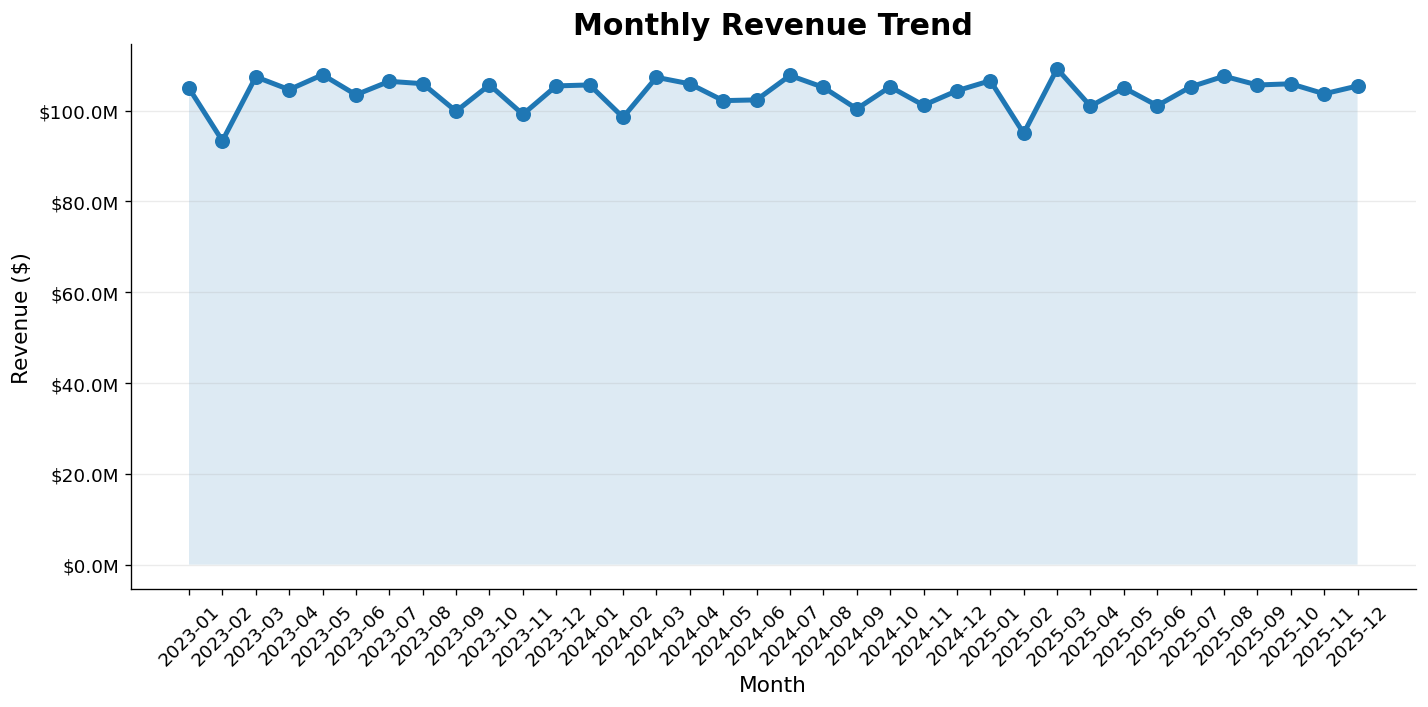

In [15]:
from matplotlib.ticker import FuncFormatter

plt.figure()

plt.plot(
    monthly_revenue["MonthYear"],
    monthly_revenue["Revenue"],
    marker="o",
    markersize=8,
    linewidth=3
)

plt.fill_between(
    monthly_revenue["MonthYear"],
    monthly_revenue["Revenue"],
    alpha=0.15
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [17]:
## TOP FIVE REVENUE MONTHS

monthly_revenue.sort_values(
    "Revenue",
    ascending=False
).head(5)

,MonthYear,Revenue
26,2025-03,"109,206,672.40"
4,2023-05,"107,893,013.92"
18,2024-07,"107,742,486.00"
31,2025-08,"107,578,783.06"
2,2023-03,"107,438,781.60"


In [18]:
## REVENUE GROWTH %

monthly_revenue["Revenue Growth (%)"] = (
    monthly_revenue["Revenue"]
    .pct_change()*100
).round(2)

monthly_revenue

,MonthYear,Revenue,Revenue Growth (%)
0,2023-01,"104,919,765.50",NaN
1,2023-02,"93,340,867.99",-11.04
2,2023-03,"107,438,781.60",15.10
3,2023-04,"104,614,585.80",-2.63
4,2023-05,"107,893,013.92",3.13
5,2023-06,"103,484,296.69",-4.09
6,2023-07,"106,445,762.01",2.86
7,2023-08,"105,927,100.03",-0.49
8,2023-09,"99,857,885.81",-5.73
9,2023-10,"105,668,672.62",5.82


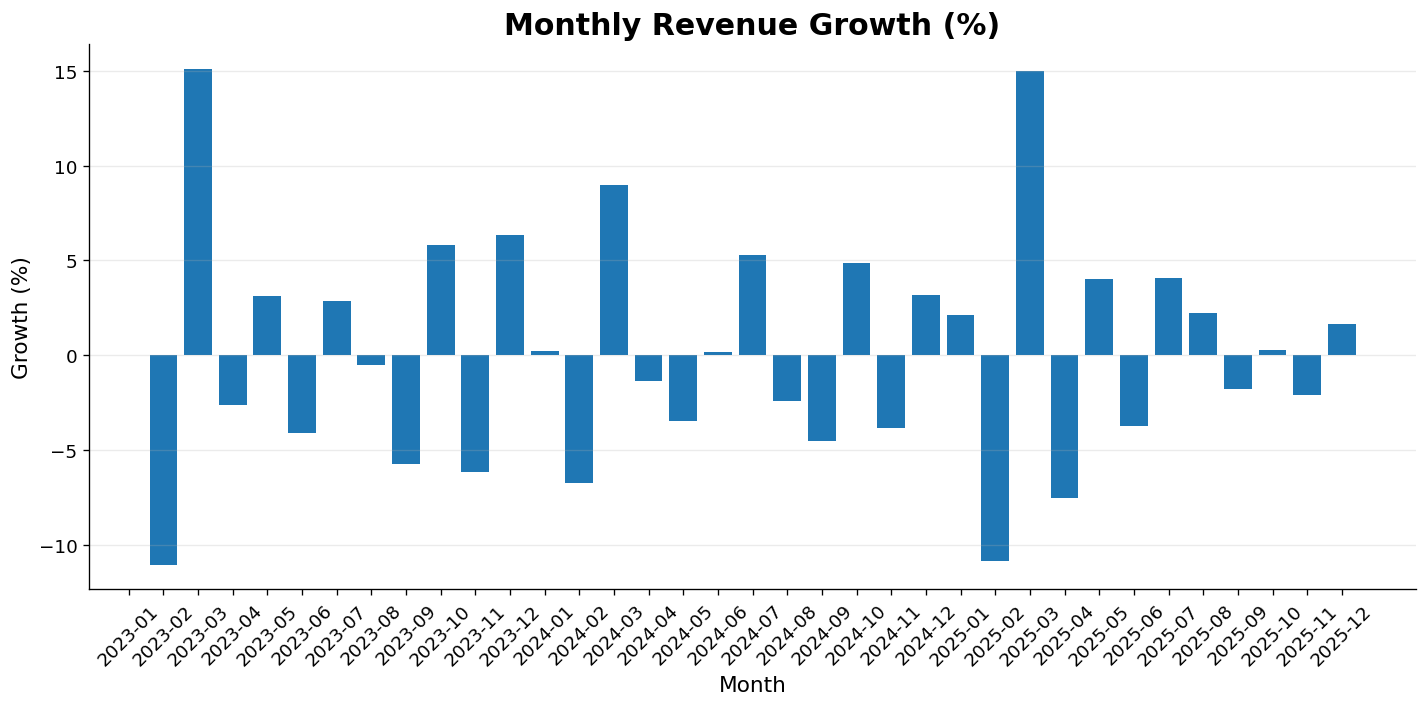

In [19]:
plt.figure()

plt.bar(
    monthly_revenue["MonthYear"],
    monthly_revenue["Revenue Growth (%)"]
)

plt.title("Monthly Revenue Growth (%)")

plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

### Key Insights

- Revenue trends indicate how business performance changes over time.
- The top-performing months can be used to identify seasonal demand.
- Revenue growth highlights periods of business expansion or slowdown.

### Conclusion

Revenue analysis provides a clear view of business growth and establishes the foundation for profitability and operational performance analysis.    

# EDA 5: Profit Analysis

## Objective

Evaluate the company's profitability by analyzing key profit KPIs and monthly profit trends.

In [21]:
# Profit KPIs

total_profit = transactions["Profit"].sum()

average_profit = transactions["Profit"].mean()

profit_margin = (
    transactions["Profit"].sum() /
    transactions["Revenue"].sum()
) * 100

profit_kpis = pd.DataFrame({
    "KPI": [
        "Total Profit",
        "Average Profit",
        "Profit Margin (%)"
    ],
    "Value": [
        f"${total_profit:,.2f}",
        f"${average_profit:,.2f}",
        f"{profit_margin:.2f}%"
    ]
})

profit_kpis.style.hide(axis="index")

KPI,Value
Total Profit,"$900,727,177.56"
Average Profit,"$4,503.64"
Profit Margin (%),24.07%


In [22]:
# Monthly Profit

monthly_profit = (
    transactions
    .groupby("MonthYear", as_index=False)["Profit"]
    .sum()
)

monthly_profit.head()

,MonthYear,Profit
0,2023-01,"25,313,292.51"
1,2023-02,"22,655,005.02"
2,2023-03,"25,905,142.26"
3,2023-04,"25,037,070.88"
4,2023-05,"26,288,007.36"


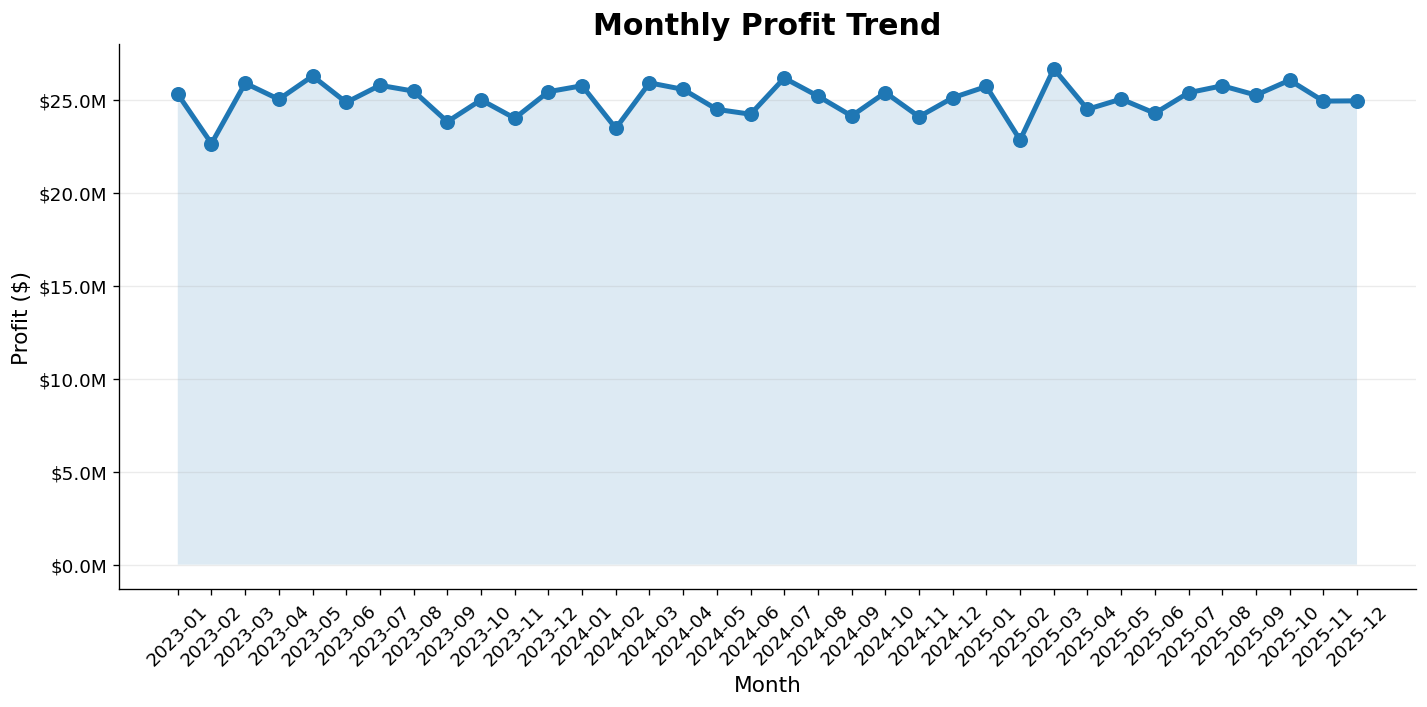

In [23]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))

plt.plot(
    monthly_profit["MonthYear"],
    monthly_profit["Profit"],
    marker="o",
    markersize=8,
    linewidth=3
)

plt.fill_between(
    monthly_profit["MonthYear"],
    monthly_profit["Profit"],
    alpha=0.15
)

plt.title("Monthly Profit Trend", fontsize=18, fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Profit ($)")

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [24]:
## TOP FIVE PROFIT MONTHS

top_profit_months = (
    monthly_profit
    .sort_values("Profit", ascending=False)
    .head(5)
)

top_profit_months

,MonthYear,Profit
26,2025-03,"26,678,741.01"
4,2023-05,"26,288,007.36"
18,2024-07,"26,180,355.81"
33,2025-10,"26,065,378.24"
14,2024-03,"25,922,408.38"


In [25]:
## MONTHLY PROFIT GROWTH
monthly_profit["Profit Growth (%)"] = (
    monthly_profit["Profit"]
    .pct_change() * 100
).round(2)

monthly_profit

,MonthYear,Profit,Profit Growth (%)
0,2023-01,"25,313,292.51",NaN
1,2023-02,"22,655,005.02",-10.50
2,2023-03,"25,905,142.26",14.35
3,2023-04,"25,037,070.88",-3.35
4,2023-05,"26,288,007.36",5.00
5,2023-06,"24,870,267.54",-5.39
6,2023-07,"25,789,661.82",3.70
7,2023-08,"25,476,789.16",-1.21
8,2023-09,"23,831,275.12",-6.46
9,2023-10,"25,005,166.36",4.93


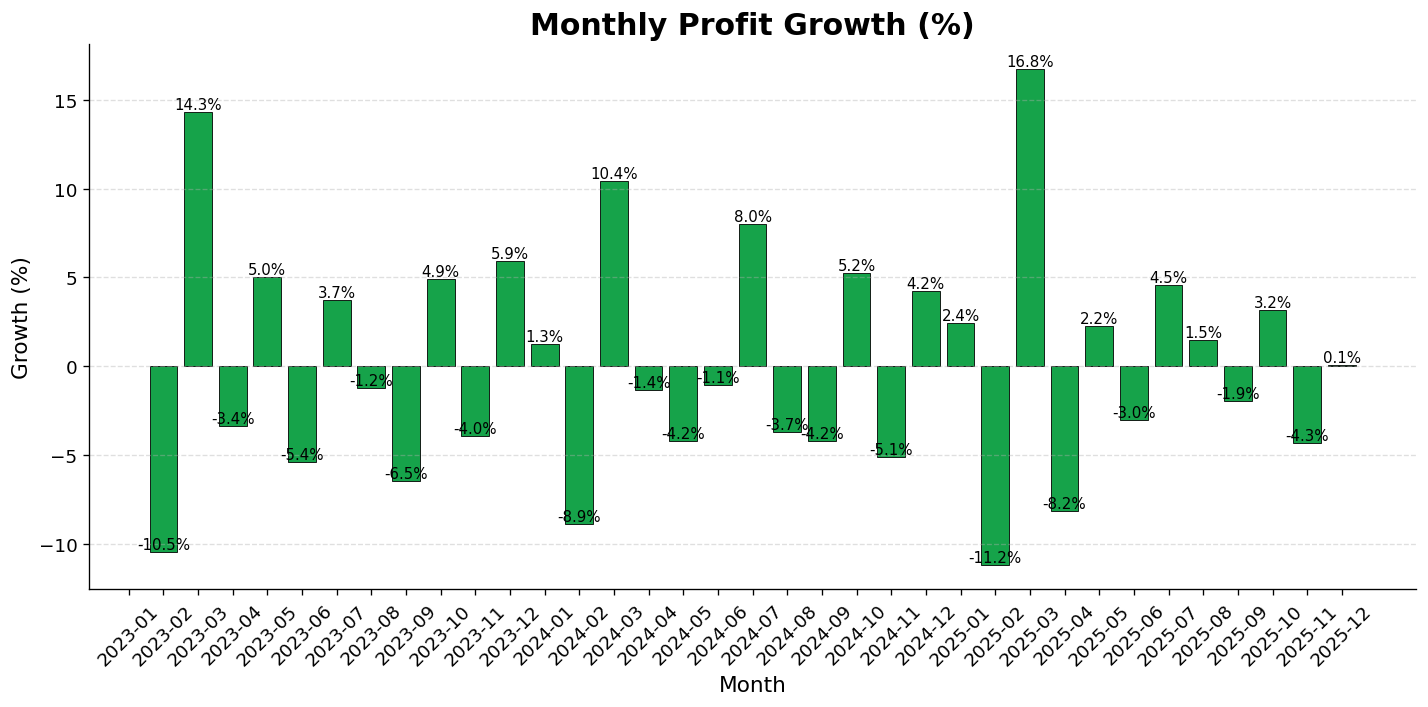

In [28]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_profit["MonthYear"],
    monthly_profit["Profit Growth (%)"],
    color="#16A34A",
    edgecolor="black",
    linewidth=0.5
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Monthly Profit Growth (%)", fontsize=18, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Key Insights

- Profit trends indicate the company's financial performance over time.
- Comparing revenue and profit helps evaluate operational efficiency.
- Profit growth highlights periods of improved or declining profitability.

### Conclusion

The company maintained measurable profitability throughout the analysis period. Monitoring profit trends alongside revenue supports better financial planning and strategic decision-making.    

# EDA 6: Expense Analysis

## Objective

Analyze the company's major expense components to understand their impact on overall profitability and identify key cost drivers.

In [29]:
# Expense KPIs

total_cogs = transactions["COGS"].sum()
total_operating_expense = transactions["OperatingExpense"].sum()
total_discount = transactions["Discount"].sum()
total_tax = transactions["Tax"].sum()

expense_kpis = pd.DataFrame({
    "Expense": [
        "COGS",
        "Operating Expense",
        "Discount",
        "Tax"
    ],
    "Amount": [
        total_cogs,
        total_operating_expense,
        total_discount,
        total_tax
    ]
})

expense_kpis["Amount"] = expense_kpis["Amount"].map("${:,.2f}".format)

expense_kpis.style.hide(axis="index")

Expense,Amount
COGS,"$1,997,896,320.72"
Operating Expense,"$655,997,510.33"
Discount,"$186,873,272.36"
Tax,"$266,432,678.88"


In [30]:
## EXPENSE SUMMARY

expense_summary = pd.DataFrame({
    "Expense": ["COGS", "Operating Expense", "Discount", "Tax"],
    "Amount": [
        total_cogs,
        total_operating_expense,
        total_discount,
        total_tax
    ]
})

expense_summary

,Expense,Amount
0,COGS,"1,997,896,320.72"
1,Operating Expense,"655,997,510.33"
2,Discount,"186,873,272.36"
3,Tax,"266,432,678.88"


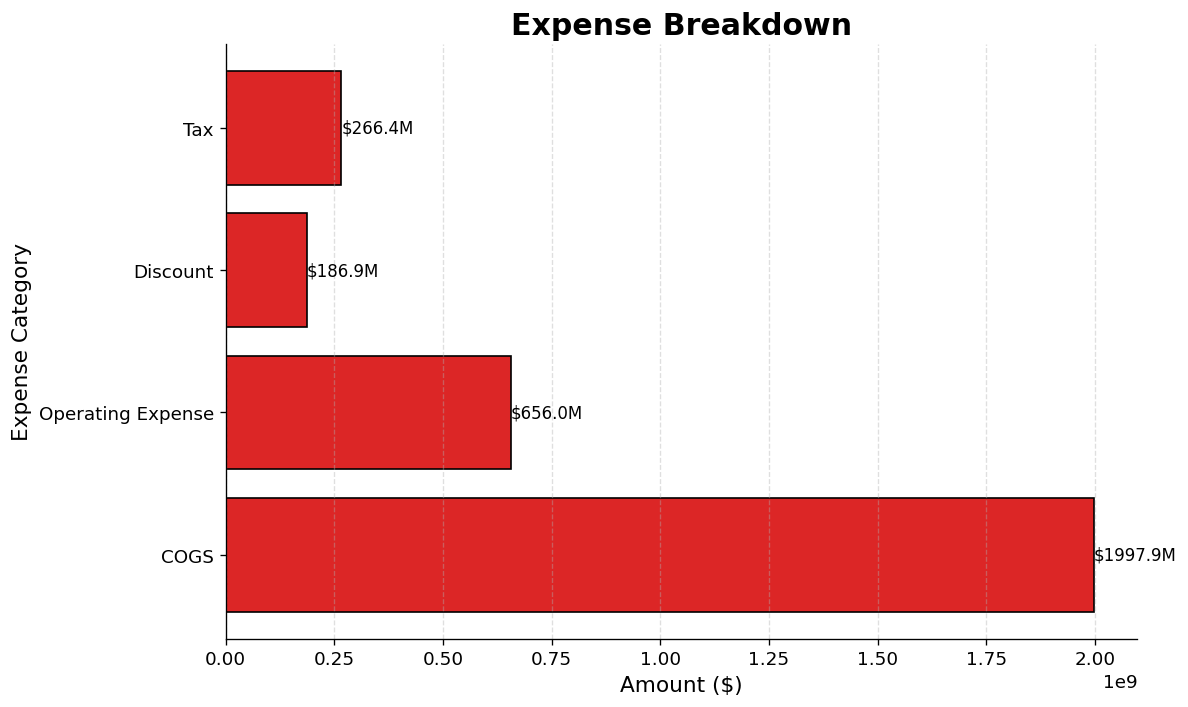

In [31]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    expense_summary["Expense"],
    expense_summary["Amount"],
    color="#DC2626",
    edgecolor="black"
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.1f}M",
        va="center",
        fontsize=10
    )

plt.title("Expense Breakdown", fontsize=18, fontweight="bold")

plt.xlabel("Amount ($)")
plt.ylabel("Expense Category")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [33]:
## MONTHLY EXPENSE TREND

monthly_expense = (
    transactions
    .groupby("MonthYear", as_index=False)[
        ["COGS", "OperatingExpense"]
    ]
    .sum()
)

monthly_expense.head()

,MonthYear,COGS,OperatingExpense
0,2023-01,"55,779,733.04","18,537,680.26"
1,2023-02,"49,845,093.58","16,241,069.97"
2,2023-03,"57,276,037.72","18,911,627.81"
3,2023-04,"55,996,593.13","18,236,625.08"
4,2023-05,"57,509,349.41","18,757,353.77"


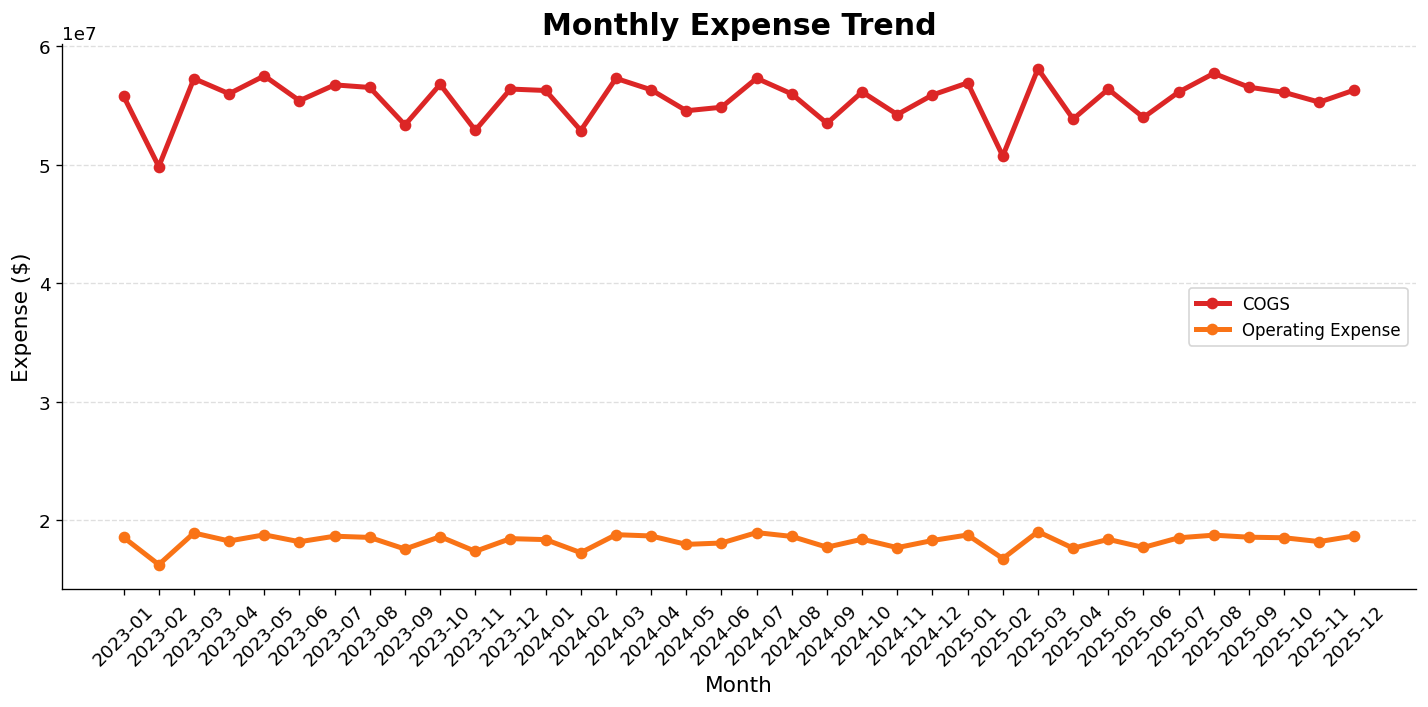

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_expense["MonthYear"],
    monthly_expense["COGS"],
    marker="o",
    linewidth=3,
    color="#DC2626",
    label="COGS"
)

plt.plot(
    monthly_expense["MonthYear"],
    monthly_expense["OperatingExpense"],
    marker="o",
    linewidth=3,
    color="#F97316",
    label="Operating Expense"
)

plt.title("Monthly Expense Trend", fontsize=18, fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Expense ($)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()

plt.show()

### Key Insights

- COGS represents the largest share of total expenses.
- Operating expenses remain relatively stable across the analysis period.
- Managing expenses effectively is essential for improving profitability.

### Conclusion

Expense analysis highlights the primary cost drivers affecting business performance. Continuous monitoring of COGS and operating expenses can support better cost control and improved profit margins.    

# EDA 7: Regional Performance Analysis

## Objective

Compare the financial performance of each region based on revenue, profit, orders, and profit margin.

In [35]:
# Merge Transactions with Regions

region_analysis = transactions.merge(
    regions,
    on="RegionID",
    how="left"
)

region_analysis.head()

,TransactionID,TransactionDate,CustomerID,ProductID,EmployeeID,DepartmentID,BusinessUnitID,RegionID,Quantity,UnitPrice,Revenue,COGS,OperatingExpense,Discount,Tax,Profit,SalesChannel,PaymentMethod,CustomerType,OrderStatus,MonthYear,RegionName,Country,Market
0,1,2024-08-17,23655,276,1967,3,1,6,2,"2,000.77","4,001.54","2,121.00",523.36,0.00,337.36,"1,357.18",Partner,Card,Individual,Completed,2024-08,Africa,South Africa,MEA
1,2,2024-12-22,15796,485,416,16,8,2,19,138.19,"2,625.61","1,799.30",444.87,0.00,257.86,381.44,Online,Card,SMB,Completed,2024-12,South America,Brazil,LATAM
2,3,2023-06-29,861,428,1766,5,7,4,17,"2,915.99","49,571.83","24,054.83","5,189.63","7,435.77","2,279.48","12,891.60",Online,Bank Transfer,Individual,Completed,2023-06,Eastern Europe,Poland,EMEA
3,4,2024-07-30,5391,427,1296,8,2,9,2,191.99,383.98,275.84,95.54,38.40,17.63,-25.80,Partner,Card,SMB,Completed,2024-07,Southeast Asia,Singapore,APAC
4,5,2023-06-23,21576,59,2205,14,8,8,6,"3,457.26","20,743.56","9,051.12","4,275.52","1,037.18","1,465.03","6,379.74",Partner,Wallet,Enterprise,Returned,2023-06,East Asia,Japan,APAC


In [36]:
## REGIONAL PERFORMANCE SUMMARY

regional_summary = (
    region_analysis
    .groupby("RegionName")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("TransactionID", "count"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

regional_summary["Profit Margin (%)"] = (
    regional_summary["Total_Profit"]
    / regional_summary["Total_Revenue"]
    * 100
).round(2)

regional_summary["Revenue Contribution (%)"] = (
    regional_summary["Total_Revenue"]
    / regional_summary["Total_Revenue"].sum()
    * 100
).round(2)

regional_summary

,RegionName,Total_Revenue,Total_Profit,Total_Orders,Total_Quantity,Profit Margin (%),Revenue Contribution (%)
0,Africa,"340,356,289.18","81,198,318.60",18148,182624,23.86,9.10
1,Central America,"340,408,122.16","81,890,570.19",18340,183252,24.06,9.10
2,East Asia,"341,123,191.43","82,333,026.87",18127,182322,24.14,9.12
3,Eastern Europe,"339,959,068.92","82,298,801.91",18066,180904,24.21,9.09
4,Middle East,"339,891,987.33","82,260,380.30",18236,181706,24.20,9.08
5,North America,"339,543,929.95","81,777,074.96",18170,180980,24.08,9.08
6,Oceania,"339,381,773.36","82,288,214.06",18223,181995,24.25,9.07
7,South America,"343,073,676.60","82,186,914.12",18293,184133,23.96,9.17
8,South Asia,"342,562,139.01","82,004,559.96",18276,183656,23.94,9.16
9,Southeast Asia,"340,424,425.95","82,410,574.80",18065,181408,24.21,9.10


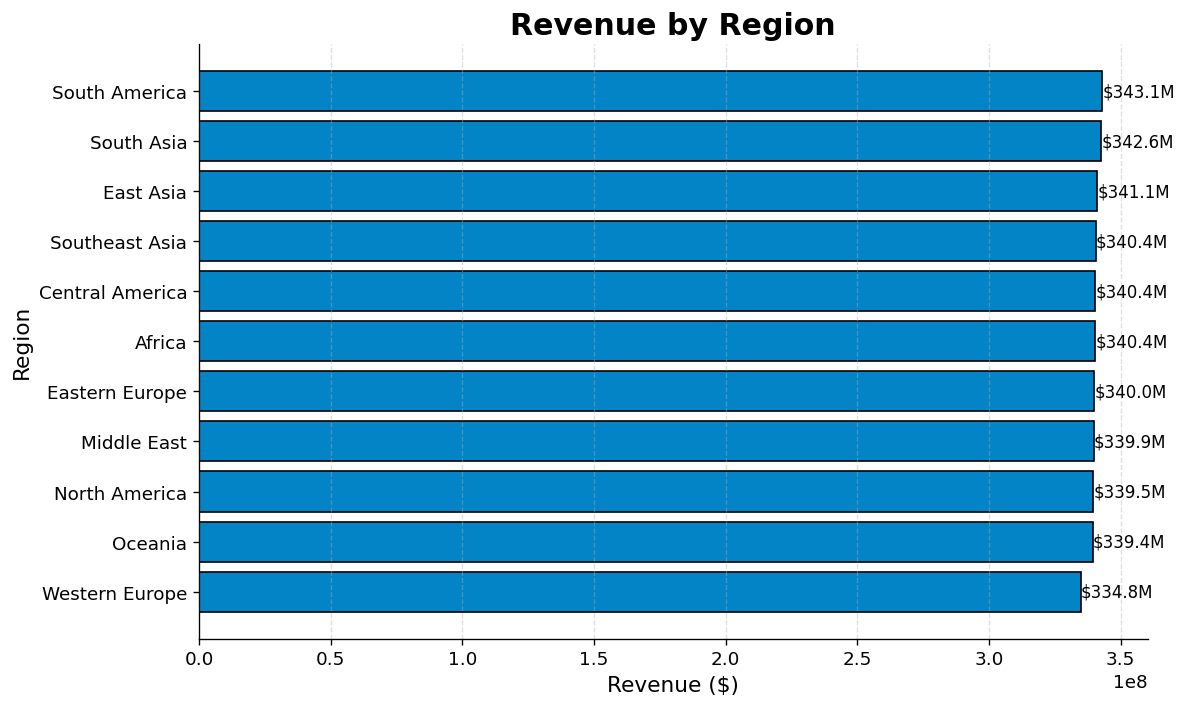

In [37]:
## REVENUE BY REGION

plt.figure(figsize=(10,6))

regional_chart = regional_summary.sort_values(
    "Total_Revenue",
    ascending=True
)

bars = plt.barh(
    regional_chart["RegionName"],
    regional_chart["Total_Revenue"],
    color="#0284C7",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.1f}M",
        va="center",
        fontsize=10
    )

plt.title("Revenue by Region", fontsize=18, fontweight="bold")

plt.xlabel("Revenue ($)")
plt.ylabel("Region")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

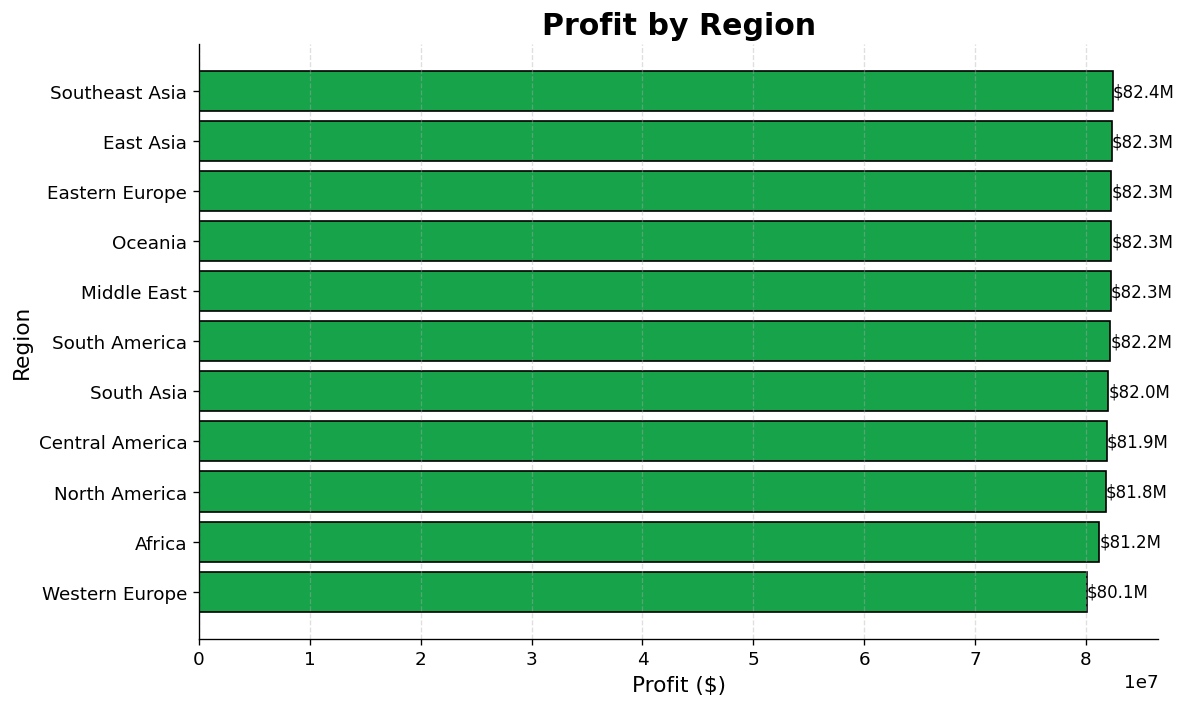

In [39]:
## PROFIT BY REGION

plt.figure(figsize=(10,6))

regional_chart = regional_summary.sort_values(
    "Total_Profit",
    ascending=True
)

bars = plt.barh(
    regional_chart["RegionName"],
    regional_chart["Total_Profit"],
    color="#16A34A",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.1f}M",
        va="center",
        fontsize=10
    )

plt.title("Profit by Region", fontsize=18, fontweight="bold")

plt.xlabel("Profit ($)")
plt.ylabel("Region")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [40]:
## REVENUE CONTRIBUTION

regional_summary[
    ["RegionName", "Revenue Contribution (%)"]
].sort_values(
    "Revenue Contribution (%)",
    ascending=False
)

,RegionName,Revenue Contribution (%)
7,South America,9.17
8,South Asia,9.16
2,East Asia,9.12
1,Central America,9.10
0,Africa,9.10
9,Southeast Asia,9.10
3,Eastern Europe,9.09
4,Middle East,9.08
5,North America,9.08
6,Oceania,9.07


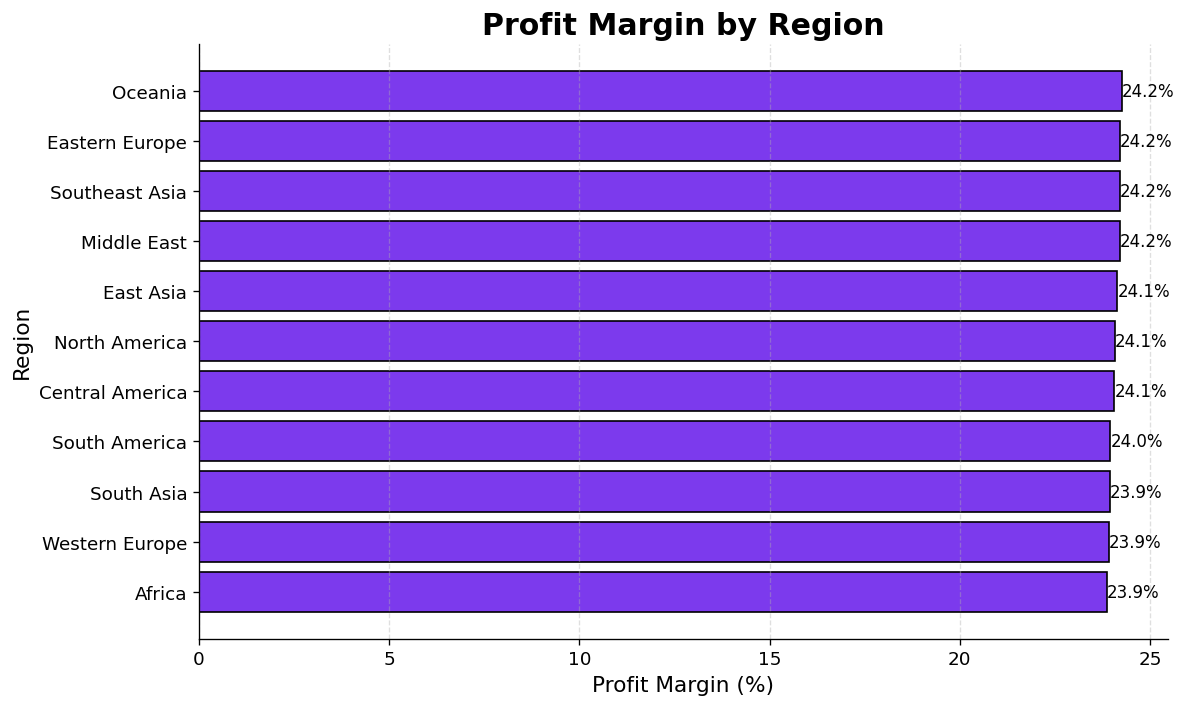

In [41]:
## PROFIT MARGIN BY REGION

plt.figure(figsize=(10,6))

regional_chart = regional_summary.sort_values(
    "Profit Margin (%)",
    ascending=True
)

bars = plt.barh(
    regional_chart["RegionName"],
    regional_chart["Profit Margin (%)"],
    color="#7C3AED",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

plt.title("Profit Margin by Region", fontsize=18, fontweight="bold")

plt.xlabel("Profit Margin (%)")
plt.ylabel("Region")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [42]:
## TOP 3 AND BOTTOM 3 REGIONS

print("Top 3 Regions by Revenue")
display(
    regional_summary.nlargest(
        3,
        "Total_Revenue"
    )[["RegionName", "Total_Revenue"]]
)

print("Bottom 3 Regions by Revenue")
display(
    regional_summary.nsmallest(
        3,
        "Total_Revenue"
    )[["RegionName", "Total_Revenue"]]
)

Top 3 Regions by Revenue


,RegionName,Total_Revenue
7,South America,"343,073,676.60"
8,South Asia,"342,562,139.01"
2,East Asia,"341,123,191.43"


Bottom 3 Regions by Revenue


,RegionName,Total_Revenue
10,Western Europe,"334,769,677.08"
6,Oceania,"339,381,773.36"
5,North America,"339,543,929.95"


### Key Insights

- Revenue varies across regions, indicating differences in market performance.
- Higher revenue does not always result in higher profit margins.
- Profit margin helps identify the most operationally efficient regions.

### Conclusion

Regional performance analysis highlights the strongest and weakest markets, supporting better resource allocation and business expansion decisions.    

# EDA 8: Product Performance Analysis

## Objective

Evaluate product performance by analyzing revenue, profit, and sales quantity to identify the best-performing products and categories.

In [43]:
product_analysis = transactions.merge(
    products,
    on="ProductID",
    how="left"
)

product_analysis.head()

,TransactionID,TransactionDate,CustomerID,ProductID,EmployeeID,DepartmentID,BusinessUnitID,RegionID,Quantity,UnitPrice_x,Revenue,COGS,OperatingExpense,Discount,Tax,Profit,SalesChannel,PaymentMethod,CustomerType,OrderStatus,MonthYear,ProductName,Category,Brand,UnitCost,UnitPrice_y,LaunchDate,ProductStatus
0,1,2024-08-17,23655,276,1967,3,1,6,2,"2,000.77","4,001.54","2,121.00",523.36,0.00,337.36,"1,357.18",Partner,Card,Individual,Completed,2024-08,Nexus Analytics Dashboard v3,Software,Nexus,"1,060.50","2,000.77",2021-07-11,Active
1,2,2024-12-22,15796,485,416,16,8,2,19,138.19,"2,625.61","1,799.30",444.87,0.00,257.86,381.44,Online,Card,SMB,Completed,2024-12,ApexTech Power Bank v3,Accessories,ApexTech,94.70,138.19,2023-03-23,Pending
2,3,2023-06-29,861,428,1766,5,7,4,17,"2,915.99","49,571.83","24,054.83","5,189.63","7,435.77","2,279.48","12,891.60",Online,Bank Transfer,Individual,Completed,2023-06,Titan IT Support Contract v5,Services,Titan,"1,414.99","2,915.99",2022-09-20,Active
3,4,2024-07-30,5391,427,1296,8,2,9,2,191.99,383.98,275.84,95.54,38.40,17.63,-25.80,Partner,Card,SMB,Completed,2024-07,Titan Implementation Consulting v2,Services,Titan,137.92,191.99,2022-11-09,Active
4,5,2023-06-23,21576,59,2205,14,8,8,6,"3,457.26","20,743.56","9,051.12","4,275.52","1,037.18","1,465.03","6,379.74",Partner,Wallet,Enterprise,Returned,2023-06,Aura Power Bank v3,Accessories,Aura,"1,508.52","3,457.26",2024-08-02,Active


In [44]:
## PRODUCT PERFORMANCE SUMMARY

product_summary = (
    product_analysis
    .groupby(["ProductName", "Category"])
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Total_Orders=("TransactionID", "count")
    )
    .reset_index()
)

product_summary["Profit Margin (%)"] = (
    product_summary["Total_Profit"]
    / product_summary["Total_Revenue"]
    * 100
).round(2)

product_summary.head()

,ProductName,Category,Total_Revenue,Total_Profit,Total_Quantity,Total_Orders,Profit Margin (%)
0,ApexTech Analytics Dashboard v2,Software,"13,885,352.40","3,004,466.10",4045,389,21.64
1,ApexTech Analytics Dashboard v3,Software,"9,380,430.55","1,828,249.83",4115,416,19.49
2,ApexTech Analytics Dashboard v5,Software,"9,660,524.95","-442,370.56",4205,416,-4.58
3,ApexTech Antivirus License v1,Software,"11,922,047.46","1,919,449.25",7814,782,16.10
4,ApexTech Antivirus License v2,Software,"14,905,153.84","3,724,828.64",7809,794,24.99


In [45]:
## TOP 10 PRODUCTS BY REVENUE

top_products = (
    product_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_products

,ProductName,Category,Total_Revenue,Total_Profit,Total_Quantity,Total_Orders,Profit Margin (%)
320,Zenith Managed Cloud v4,Services,"41,290,662.32","12,301,710.65",12579,1259,29.79
22,ApexTech Noise-Canceling Headset v3,Accessories,"37,989,013.53","8,293,353.05",15521,1560,21.83
147,OmniSys Implementation Consulting v5,Services,"34,369,697.54","4,232,214.36",16802,1663,12.31
133,OmniSys Analytics Dashboard v4,Software,"34,340,152.36","10,934,031.13",11578,1192,31.84
50,Aura Cloud Storage Plan v5,Software,"32,039,068.54","6,496,565.94",11620,1179,20.28
239,Titan Power Bank v2,Accessories,"29,203,180.53","9,056,646.68",7887,786,31.01
152,OmniSys Monitor 4K v1,Hardware,"28,822,007.52","9,864,634.35",12621,1259,34.23
286,Vortex Pro Laptop v5,Hardware,"28,205,561.49","7,812,388.57",8743,865,27.70
215,Titan Cloud Storage Plan v2,Software,"27,769,616.15","9,044,315.53",8187,804,32.57
17,ApexTech Implementation Consulting v2,Services,"26,745,701.93","6,312,365.04",12515,1241,23.60


In [46]:
## CATEGORY PERFROMANCE

category_summary = (
    product_analysis
    .groupby("Category")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

category_summary["Profit Margin (%)"] = (
    category_summary["Total_Profit"]
    / category_summary["Total_Revenue"]
    * 100
).round(2)

category_summary

,Category,Total_Revenue,Total_Profit,Total_Quantity,Profit Margin (%)
0,Accessories,"1,013,907,962.92","245,243,331.09",533431,24.19
1,Hardware,"845,815,381.11","209,763,348.28",448036,24.80
2,Services,"965,951,454.96","218,904,492.61",534237,22.66
3,Software,"915,819,481.98","226,816,005.58",487299,24.77


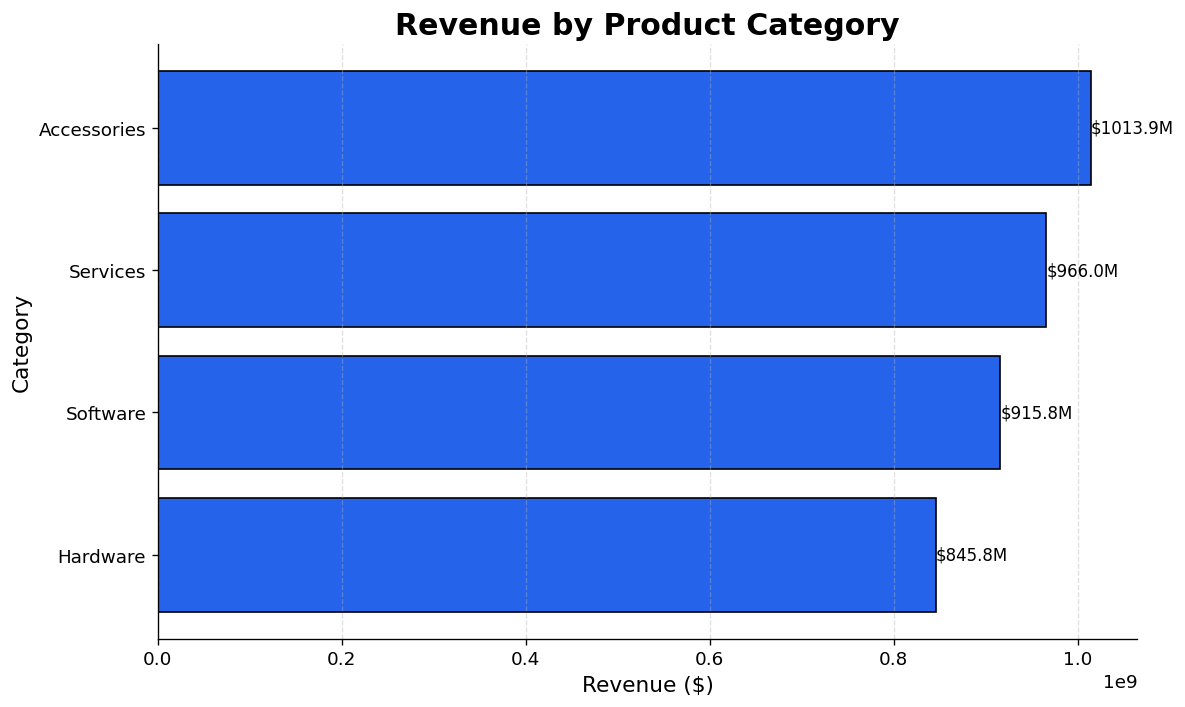

In [47]:
## REVENUE BY CATEGORY

category_chart = category_summary.sort_values(
    "Total_Revenue",
    ascending=True
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    category_chart["Category"],
    category_chart["Total_Revenue"],
    color="#2563EB",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.1f}M",
        va="center",
        fontsize=10
    )

plt.title("Revenue by Product Category", fontsize=18, fontweight="bold")

plt.xlabel("Revenue ($)")
plt.ylabel("Category")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [48]:
## TOP 10 PRODUCTS BY PROFIT

top_profit_products = (
    product_summary
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_profit_products

,ProductName,Category,Total_Revenue,Total_Profit,Total_Quantity,Total_Orders,Profit Margin (%)
320,Zenith Managed Cloud v4,Services,"41,290,662.32","12,301,710.65",12579,1259,29.79
133,OmniSys Analytics Dashboard v4,Software,"34,340,152.36","10,934,031.13",11578,1192,31.84
152,OmniSys Monitor 4K v1,Hardware,"28,822,007.52","9,864,634.35",12621,1259,34.23
239,Titan Power Bank v2,Accessories,"29,203,180.53","9,056,646.68",7887,786,31.01
215,Titan Cloud Storage Plan v2,Software,"27,769,616.15","9,044,315.53",8187,804,32.57
22,ApexTech Noise-Canceling Headset v3,Accessories,"37,989,013.53","8,293,353.05",15521,1560,21.83
78,Aura USB-C Dock v2,Accessories,"26,652,359.55","8,211,497.54",8451,852,30.81
54,Aura IT Support Contract v5,Services,"24,026,937.53","8,075,805.48",8103,822,33.61
286,Vortex Pro Laptop v5,Hardware,"28,205,561.49","7,812,388.57",8743,865,27.70
161,OmniSys SaaS Enterprise Suite v4,Software,"24,222,540.70","7,783,609.92",8856,868,32.13


### Key Insights

- A small number of products contribute a significant share of total revenue.
- Product categories differ in both revenue generation and profitability.
- High revenue products are not always the most profitable.


### Conclusion

Product performance analysis helps identify high-value products and categories, enabling better inventory planning, pricing strategies, and product portfolio decisions.

# EDA 9: Customer Analysis

## Objective

Analyze customer performance to identify high-value customers and understand the revenue contribution of different customer segments.

In [50]:
customer_analysis = transactions.merge(
    customers,
    on="CustomerID",
    how="left"
)

customer_analysis.head()

,TransactionID,TransactionDate,CustomerID,ProductID,EmployeeID,DepartmentID,BusinessUnitID,RegionID,Quantity,UnitPrice,Revenue,COGS,OperatingExpense,Discount,Tax,Profit,SalesChannel,PaymentMethod,CustomerType_x,OrderStatus,MonthYear,FirstName,LastName,Gender,Age,City,State,Country,CustomerType_y,Industry,JoinDate,LoyaltyLevel
0,1,2024-08-17,23655,276,1967,3,1,6,2,"2,000.77","4,001.54","2,121.00",523.36,0.00,337.36,"1,357.18",Partner,Card,Individual,Completed,2024-08,Lori,Mills,Female,33,Port Robert,Oregon,Liechtenstein,Individual,Retail,2024-02-01,Gold
1,2,2024-12-22,15796,485,416,16,8,2,19,138.19,"2,625.61","1,799.30",444.87,0.00,257.86,381.44,Online,Card,SMB,Completed,2024-12,Joshua,Davis,Male,48,Dianashire,New Mexico,Palestinian Territory,SMB,Education,2021-07-07,Gold
2,3,2023-06-29,861,428,1766,5,7,4,17,"2,915.99","49,571.83","24,054.83","5,189.63","7,435.77","2,279.48","12,891.60",Online,Bank Transfer,Individual,Completed,2023-06,Jennifer,Thomas,Female,26,Joemouth,Kansas,Heard Island and McDonald Islands,Individual,Manufacturing,2023-06-21,Gold
3,4,2024-07-30,5391,427,1296,8,2,9,2,191.99,383.98,275.84,95.54,38.40,17.63,-25.80,Partner,Card,SMB,Completed,2024-07,Steven,Johnson,Male,69,South Wayneborough,Colorado,Serbia,SMB,Education,2025-07-14,Bronze
4,5,2023-06-23,21576,59,2205,14,8,8,6,"3,457.26","20,743.56","9,051.12","4,275.52","1,037.18","1,465.03","6,379.74",Partner,Wallet,Enterprise,Returned,2023-06,Aaron,Anthony,Male,46,West James,Nebraska,New Zealand,Individual,Education,2021-08-07,Bronze


In [54]:
# CUSTOMER PERFORMANCE SUMMARY

customer_summary = (
    customer_analysis
    .groupby(
        ["CustomerID", "FirstName", "LastName", "CustomerType_y"],
        as_index=False
    )
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("TransactionID", "count")
    )
)

customer_summary["Customer Name"] = (
    customer_summary["FirstName"] + " " + customer_summary["LastName"]
)

customer_summary["Profit Margin (%)"] = (
    customer_summary["Total_Profit"]
    / customer_summary["Total_Revenue"] * 100
).round(2)

customer_summary.head()

,CustomerID,FirstName,LastName,CustomerType_y,Total_Revenue,Total_Profit,Total_Orders,Customer Name,Profit Margin (%)
0,1,Danny,Jones,Individual,"146,802.87","27,577.36",9,Danny Jones,18.79
1,2,Cynthia,Wells,SMB,"211,016.15","41,494.30",10,Cynthia Wells,19.66
2,3,Carol,Lawson,Enterprise,"149,890.50","37,577.47",8,Carol Lawson,25.07
3,4,Emily,Byrd,Individual,"186,087.95","35,801.18",11,Emily Byrd,19.24
4,5,Michael,Burton,Enterprise,"167,486.37","31,561.02",6,Michael Burton,18.84


In [56]:
## TOP 10 CUSTOMERS BY REVENUE

top_customers = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers[
    [
        "Customer Name",
        "Total_Revenue",
        "Total_Profit",
        "Total_Orders"
    ]
]

,Customer Name,Total_Revenue,Total_Profit,Total_Orders
23573,Brittney Flores,"508,839.06","143,555.40",21
17905,Amber Gray,"507,985.76","118,277.48",19
18578,Chelsea Benjamin,"492,155.67","152,274.69",14
4937,John Williams,"485,179.80","142,051.45",17
17140,Gregory Choi,"476,805.90","126,675.16",15
21654,Robin Atkinson,"474,671.01","142,859.98",13
4561,Amy Walters,"464,450.51","154,440.25",17
12691,Stephen Escobar,"456,891.27","105,986.26",15
20692,Jeff Ryan,"456,839.03","108,076.57",15
12610,Alexis Sweeney,"456,752.25","103,597.84",14


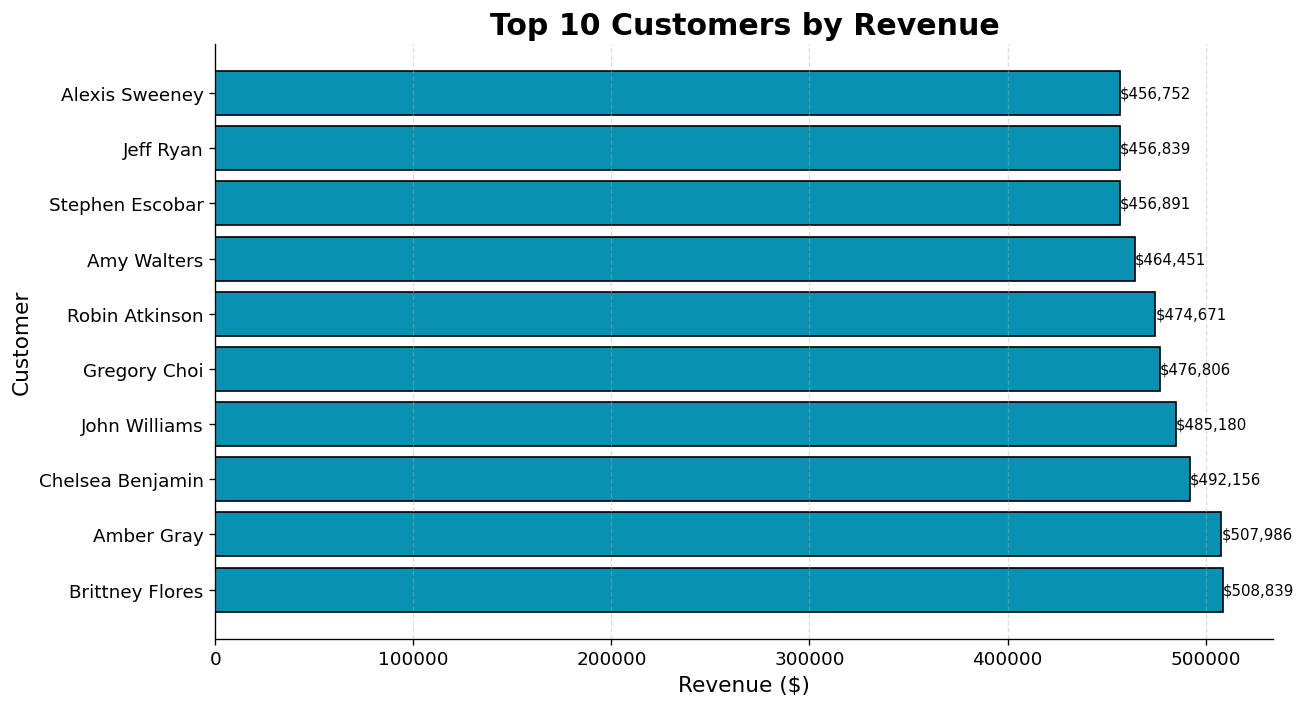

In [57]:
## TOP 10 CUSTOMERS CHART

plt.figure(figsize=(11,6))

bars = plt.barh(
    top_customers["Customer Name"],
    top_customers["Total_Revenue"],
    color="#0891B2",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.title("Top 10 Customers by Revenue", fontsize=18, fontweight="bold")

plt.xlabel("Revenue ($)")
plt.ylabel("Customer")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [59]:
## CUSTOMER TYPE PERFORMANCE

customer_type_summary = (
    customer_analysis
    .groupby("CustomerType_y", as_index=False)
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("TransactionID", "count")
    )
)

customer_type_summary["Revenue Contribution (%)"] = (
    customer_type_summary["Total_Revenue"]
    / customer_type_summary["Total_Revenue"].sum()
    * 100
).round(2)

customer_type_summary

,CustomerType_y,Total_Revenue,Total_Profit,Total_Orders,Revenue Contribution (%)
0,Enterprise,"737,945,863.09","177,012,532.00",39800,19.72
1,Individual,"1,691,240,500.74","406,578,070.80",90210,45.20
2,SMB,"1,312,307,917.14","317,136,574.76",69990,35.07


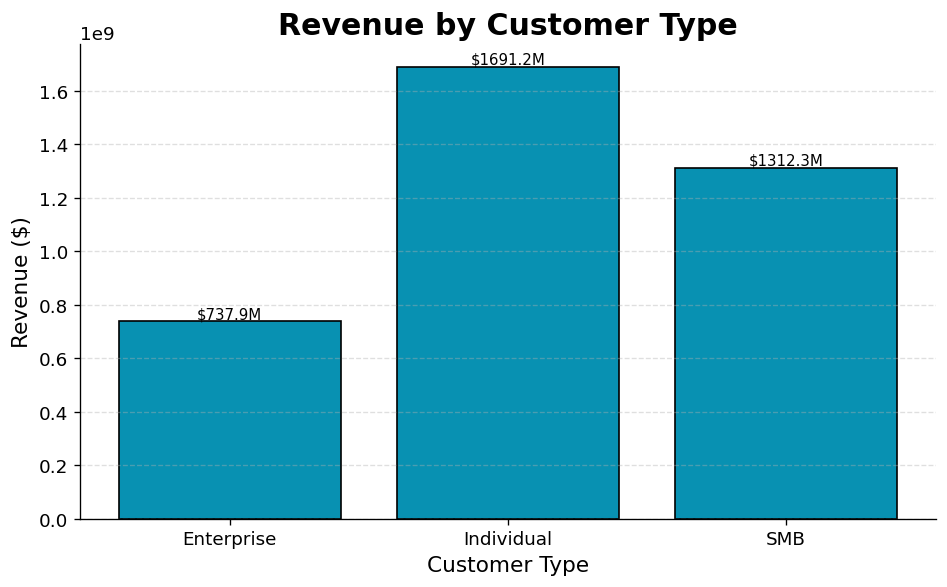

In [61]:
## REVENUE BY CUSTOMER TYPE

plt.figure(figsize=(8,5))

bars = plt.bar(
    customer_type_summary["CustomerType_y"],
    customer_type_summary["Total_Revenue"],
    color="#0891B2",
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height/1_000_000:.1f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Revenue by Customer Type", fontsize=18, fontweight="bold")

plt.xlabel("Customer Type")
plt.ylabel("Revenue ($)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [62]:
## TOP 10 CUSTOMERS BY PROFIT

top_profit_customers = (
    customer_summary
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_profit_customers[
    [
        "Customer Name",
        "Total_Profit"
    ]
]

,Customer Name,Total_Profit
4561,Amy Walters,"154,440.25"
18578,Chelsea Benjamin,"152,274.69"
22765,Brian Kirk,"150,804.21"
23573,Brittney Flores,"143,555.40"
21654,Robin Atkinson,"142,859.98"
1234,John Nichols,"142,207.67"
4937,John Williams,"142,051.45"
2693,Alexis Peterson,"141,043.93"
1940,Robin Ford,"137,673.36"
7189,Paula Walsh,"135,483.86"


### Key Insights

- A small group of customers contributes a significant share of total revenue.
- Customer segments differ in revenue generation and profitability.
- Identifying high-value customers helps improve customer retention and targeted marketing strategies.

### Conclusion

Customer analysis highlights the company's most valuable customers and customer segments, enabling better relationship management and revenue growth strategies.    

# EDA 10: Employee Performance Analysis

## Objective

Evaluate employee performance by analyzing revenue, profit, and order volume to identify top-performing employees.

In [63]:
employee_analysis = transactions.merge(
    employees,
    on="EmployeeID",
    how="left",
    suffixes=("", "_Employee")
)

employee_analysis.head()

,TransactionID,TransactionDate,CustomerID,ProductID,EmployeeID,DepartmentID,BusinessUnitID,RegionID,Quantity,UnitPrice,Revenue,COGS,OperatingExpense,Discount,Tax,Profit,SalesChannel,PaymentMethod,CustomerType,OrderStatus,MonthYear,EmployeeName,DepartmentID_Employee,BusinessUnitID_Employee,RegionID_Employee,JobTitle,HireDate,Salary,ExperienceYears,PerformanceRating
0,1,2024-08-17,23655,276,1967,3,1,6,2,"2,000.77","4,001.54","2,121.00",523.36,0.00,337.36,"1,357.18",Partner,Card,Individual,Completed,2024-08,Deborah Durham,7,8,5,Lead Engineer,2025-05-10,"73,834.59",6,2.43
1,2,2024-12-22,15796,485,416,16,8,2,19,138.19,"2,625.61","1,799.30",444.87,0.00,257.86,381.44,Online,Card,SMB,Completed,2024-12,Jacob Sanders,1,4,5,Executive Assistant,2021-09-22,"53,676.98",5,3.87
2,3,2023-06-29,861,428,1766,5,7,4,17,"2,915.99","49,571.83","24,054.83","5,189.63","7,435.77","2,279.48","12,891.60",Online,Bank Transfer,Individual,Completed,2023-06,Stephanie Rosales,12,5,1,Executive Assistant,2019-11-27,"160,805.19",16,1.50
3,4,2024-07-30,5391,427,1296,8,2,9,2,191.99,383.98,275.84,95.54,38.40,17.63,-25.80,Partner,Card,SMB,Completed,2024-07,Olivia Oneill,20,10,8,Specialist,2024-07-26,"110,085.87",12,2.34
4,5,2023-06-23,21576,59,2205,14,8,8,6,"3,457.26","20,743.56","9,051.12","4,275.52","1,037.18","1,465.03","6,379.74",Partner,Wallet,Enterprise,Returned,2023-06,Raymond Meyer,11,3,7,Manager,2023-09-05,"131,094.00",6,4.85


In [65]:
## EMPLOYEE PERFORMANCE SUMMARY

employee_summary = (
    employee_analysis
    .groupby(
        ["EmployeeID", "EmployeeName", "JobTitle"],
        as_index=False
    )
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("TransactionID", "count"),
        Total_Quantity=("Quantity", "sum")
    )
)

employee_summary["Profit Margin (%)"] = (
    employee_summary["Total_Profit"]
    / employee_summary["Total_Revenue"] * 100
).round(2)

employee_summary.head()

,EmployeeID,EmployeeName,JobTitle,Total_Revenue,Total_Profit,Total_Orders,Total_Quantity,Profit Margin (%)
0,1,Lisa Rice,Specialist,"1,406,100.26","299,621.43",79,902,21.31
1,2,Sharon Bryant,Senior Analyst,"1,507,759.72","379,261.34",69,780,25.15
2,3,Shannon Rivas,Associate,"1,239,935.63","284,492.70",69,771,22.94
3,4,David Soto,Executive Assistant,"1,368,029.63","321,719.81",81,783,23.52
4,5,Dr. Cody Gutierrez DDS,Executive Assistant,"1,566,337.34","367,918.18",90,875,23.49


In [66]:
## TOP 10 EMPLOYEES BY REVENUE

top_employees = (
    employee_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_employees[
    [
        "EmployeeName",
        "JobTitle",
        "Total_Revenue",
        "Total_Profit",
        "Total_Orders"
    ]
]

,EmployeeName,JobTitle,Total_Revenue,Total_Profit,Total_Orders
620,Mark Myers,Lead Engineer,"2,407,331.51","571,235.32",114
213,Anthony Stevenson,Specialist,"2,403,220.19","609,496.80",111
1460,George James,Director,"2,308,995.00","572,017.59",107
1878,Melanie Rogers,Associate,"2,234,252.18","591,837.63",95
1867,Joseph Clark,Associate,"2,189,386.35","557,505.51",101
2334,Ronald Nelson,Associate,"2,188,809.90","507,514.30",106
892,Kelly Orr,Senior Analyst,"2,188,680.19","584,701.70",96
640,Robert Riddle,Executive Assistant,"2,161,364.69","472,529.45",108
2328,Glenn Davis,Executive Assistant,"2,139,614.59","555,139.14",89
1560,John Lewis,Specialist,"2,135,684.90","597,722.19",88


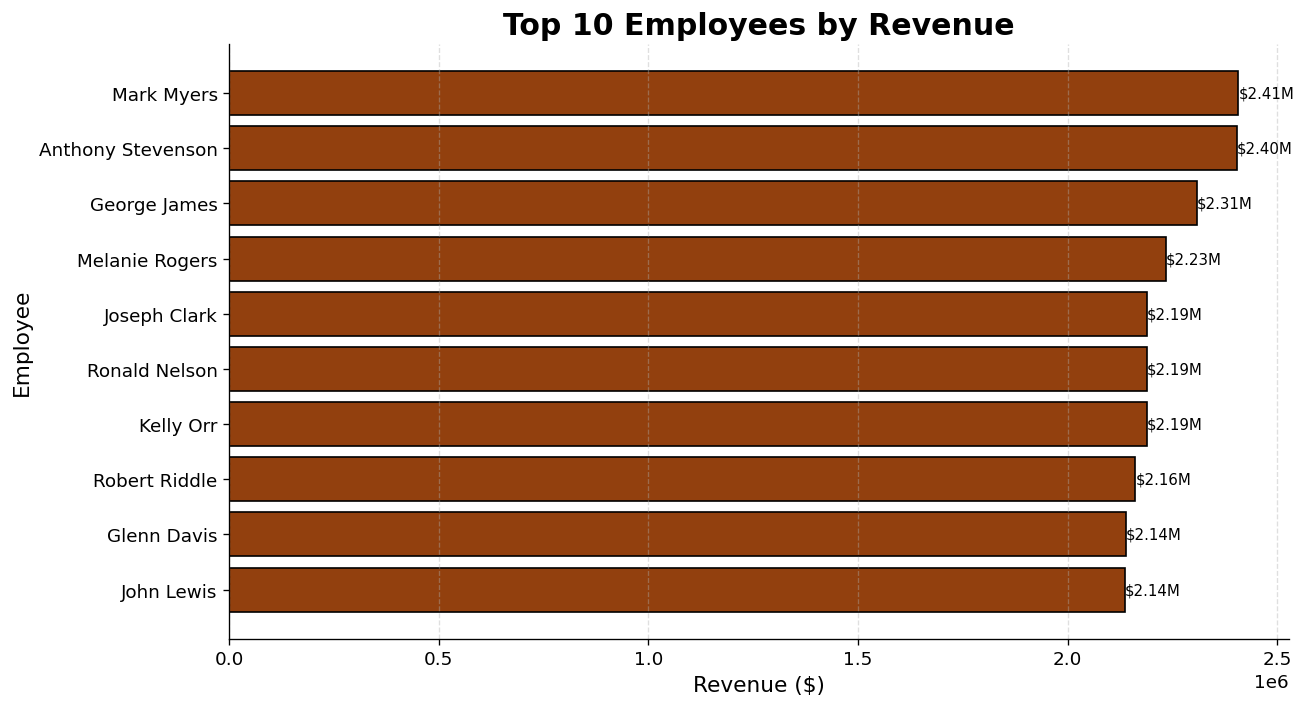

In [67]:
plt.figure(figsize=(11,6))

top_chart = top_employees.sort_values("Total_Revenue")

bars = plt.barh(
    top_chart["EmployeeName"],
    top_chart["Total_Revenue"],
    color="#92400E",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.2f}M",
        va="center",
        fontsize=9
    )

plt.title("Top 10 Employees by Revenue", fontsize=18, fontweight="bold")

plt.xlabel("Revenue ($)")
plt.ylabel("Employee")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [68]:
## TOP EMPLOYEES BY PROFIT

top_profit_employees = (
    employee_summary
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_profit_employees[
    [
        "EmployeeName",
        "JobTitle",
        "Total_Profit"
    ]
]

,EmployeeName,JobTitle,Total_Profit
213,Anthony Stevenson,Specialist,"609,496.80"
1560,John Lewis,Specialist,"597,722.19"
1878,Melanie Rogers,Associate,"591,837.63"
892,Kelly Orr,Senior Analyst,"584,701.70"
1460,George James,Director,"572,017.59"
620,Mark Myers,Lead Engineer,"571,235.32"
1554,Jennifer Torres,Associate,"567,267.04"
186,Lisa Holland,Associate,"564,412.34"
1867,Joseph Clark,Associate,"557,505.51"
2328,Glenn Davis,Executive Assistant,"555,139.14"


In [69]:
## EMPLOYEE PRODUCTIVITY

employee_productivity = (
    employee_summary
    .sort_values("Total_Orders", ascending=False)
    .head(10)
)

employee_productivity[
    [
        "EmployeeName",
        "JobTitle",
        "Total_Orders",
        "Total_Quantity"
    ]
]

,EmployeeName,JobTitle,Total_Orders,Total_Quantity
620,Mark Myers,Lead Engineer,114,1176
213,Anthony Stevenson,Specialist,111,1132
640,Robert Riddle,Executive Assistant,108,1148
438,Dr. Kristina Mcdonald DDS,Senior Analyst,107,989
1741,Frank Pineda,Executive Assistant,107,994
1524,David Vaughn,Director,107,1072
1460,George James,Director,107,1157
2334,Ronald Nelson,Associate,106,1088
1013,Sarah Evans,Executive Assistant,106,1133
398,Claudia Ramirez,Director,106,1087


### Key Insights

- Employee performance varies across revenue, profit, and order volume.
- High-performing employees contribute significantly to overall business performance.
- Productivity analysis helps identify top contributors and training opportunities.

### Conclusion

Employee performance analysis provides insights into workforce productivity and supports performance evaluation, recognition, and resource planning.    

# EDA 11: Department Performance Analysis

## Objective

Evaluate departmental performance by analyzing revenue, profit, and transaction volume to identify the highest-performing departments.

In [70]:
department_analysis = transactions.merge(
    departments,
    on="DepartmentID",
    how="left",
    suffixes=("", "_Department")
)

department_analysis.head()

,TransactionID,TransactionDate,CustomerID,ProductID,EmployeeID,DepartmentID,BusinessUnitID,RegionID,Quantity,UnitPrice,Revenue,COGS,OperatingExpense,Discount,Tax,Profit,SalesChannel,PaymentMethod,CustomerType,OrderStatus,MonthYear,DepartmentName,DepartmentHead,AnnualBudget,EmployeeCount
0,1,2024-08-17,23655,276,1967,3,1,6,2,"2,000.77","4,001.54","2,121.00",523.36,0.00,337.36,"1,357.18",Partner,Card,Individual,Completed,2024-08,Finance,Lisa Hensley,"1,238,823.73",187
1,2,2024-12-22,15796,485,416,16,8,2,19,138.19,"2,625.61","1,799.30",444.87,0.00,257.86,381.44,Online,Card,SMB,Completed,2024-12,Information Security,Judy Baker,"4,029,350.91",70
2,3,2023-06-29,861,428,1766,5,7,4,17,"2,915.99","49,571.83","24,054.83","5,189.63","7,435.77","2,279.48","12,891.60",Online,Bank Transfer,Individual,Completed,2023-06,Human Resources,Dylan Miller,"6,848,959.94",146
3,4,2024-07-30,5391,427,1296,8,2,9,2,191.99,383.98,275.84,95.54,38.40,17.63,-25.80,Partner,Card,SMB,Completed,2024-07,Procurement,Derek Zuniga,"6,303,391.15",125
4,5,2023-06-23,21576,59,2205,14,8,8,6,"3,457.26","20,743.56","9,051.12","4,275.52","1,037.18","1,465.03","6,379.74",Partner,Wallet,Enterprise,Returned,2023-06,Engineering,Tommy Walter,"2,399,315.50",108


In [72]:
## DEPARTMENT PERFORMANCE SUMMARY

department_summary = (
    department_analysis
    .groupby("DepartmentName", as_index=False)
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("TransactionID", "count"),
        Total_Quantity=("Quantity", "sum")
    )
)

department_summary["Profit Margin (%)"] = (
    department_summary["Total_Profit"]
    / department_summary["Total_Revenue"] * 100
).round(2)

department_summary

,DepartmentName,Total_Revenue,Total_Profit,Total_Orders,Total_Quantity,Profit Margin (%)
0,Administration,"185,711,662.70","44,280,735.05",9968,99577,23.84
1,Business Analytics,"194,190,512.49","47,104,440.28",10128,102312,24.26
2,Compliance,"185,877,624.88","44,602,901.16",9974,99101,24.00
3,Corporate Strategy,"185,665,091.34","44,337,040.60",10040,100271,23.88
4,Customer Success,"189,419,306.20","45,902,465.47",10007,100536,24.23
5,Data Engineering,"181,841,543.84","43,568,120.33",9897,98670,23.96
6,Engineering,"191,213,204.71","46,295,980.48",10115,101207,24.21
7,Finance,"186,096,893.00","44,414,101.69",10050,100343,23.87
8,Human Resources,"188,319,122.56","45,528,364.61",10159,101672,24.18
9,Information Security,"184,310,761.82","44,082,745.62",9950,99782,23.92


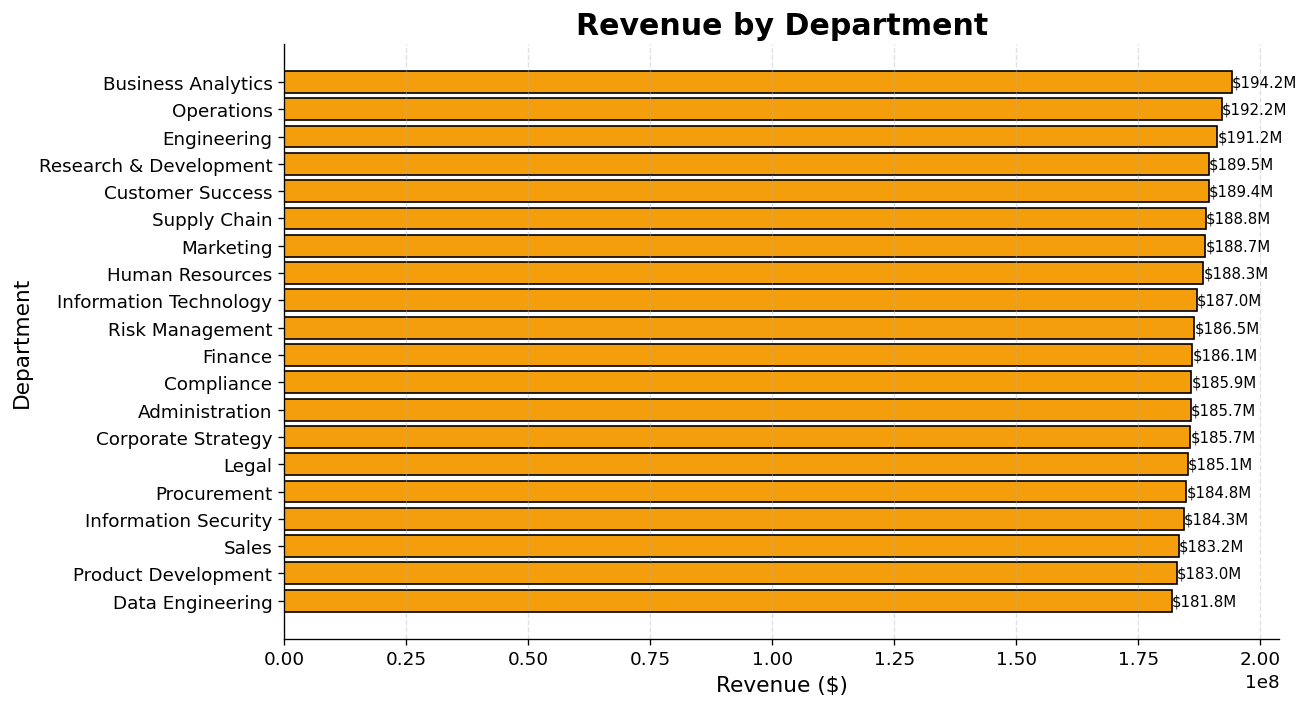

In [73]:
## REVENUE BY DEPARTMENT

department_chart = department_summary.sort_values(
    "Total_Revenue",
    ascending=True
)

plt.figure(figsize=(11,6))

bars = plt.barh(
    department_chart["DepartmentName"],
    department_chart["Total_Revenue"],
    color="#F59E0B",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.1f}M",
        va="center",
        fontsize=9
    )

plt.title("Revenue by Department", fontsize=18, fontweight="bold")

plt.xlabel("Revenue ($)")
plt.ylabel("Department")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

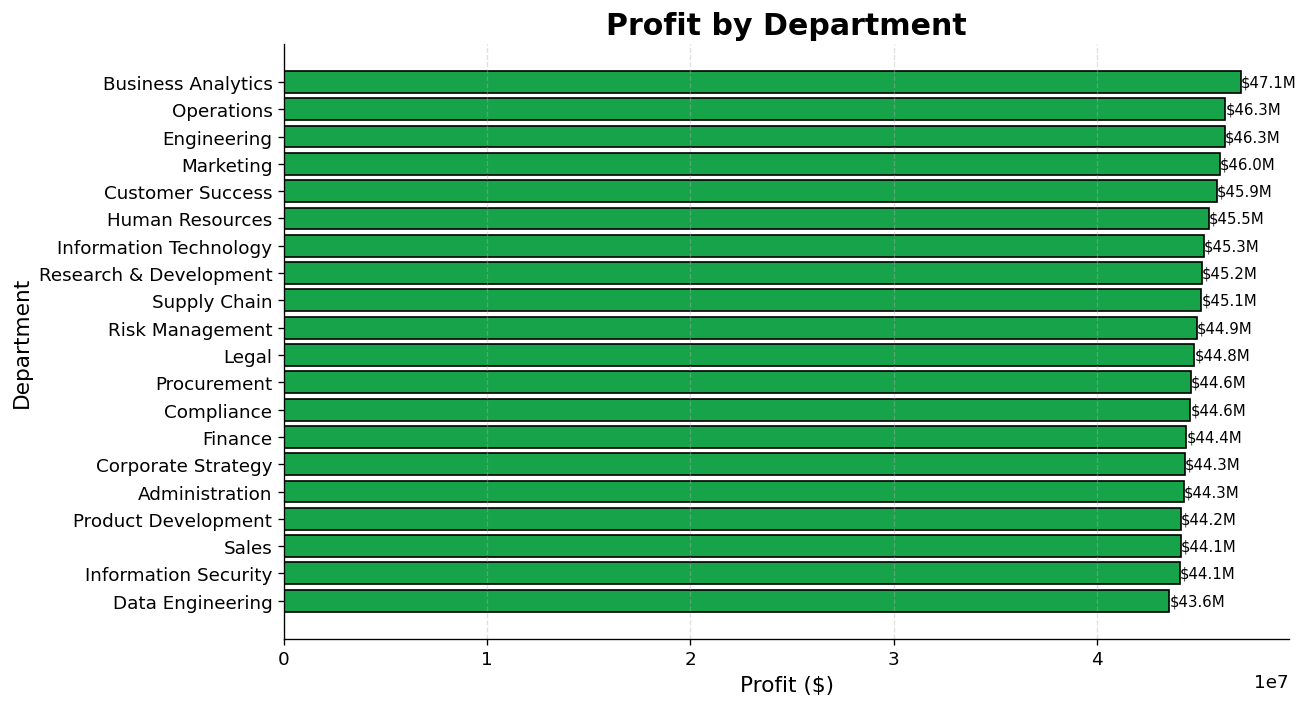

In [74]:
## PROFIT  BY DEPARTMENT

department_chart = department_summary.sort_values(
    "Total_Profit",
    ascending=True
)

plt.figure(figsize=(11,6))

bars = plt.barh(
    department_chart["DepartmentName"],
    department_chart["Total_Profit"],
    color="#16A34A",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width/1_000_000:.1f}M",
        va="center",
        fontsize=9
    )

plt.title("Profit by Department", fontsize=18, fontweight="bold")

plt.xlabel("Profit ($)")
plt.ylabel("Department")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [75]:
## TOP 5 DEPARTMENTS

top_departments = (
    department_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(5)
)

top_departments

,DepartmentName,Total_Revenue,Total_Profit,Total_Orders,Total_Quantity,Profit Margin (%)
1,Business Analytics,"194,190,512.49","47,104,440.28",10128,102312,24.26
13,Operations,"192,167,878.89","46,335,332.03",10138,102092,24.11
6,Engineering,"191,213,204.71","46,295,980.48",10115,101207,24.21
16,Research & Development,"189,464,459.84","45,157,864.67",10060,101420,23.83
4,Customer Success,"189,419,306.20","45,902,465.47",10007,100536,24.23


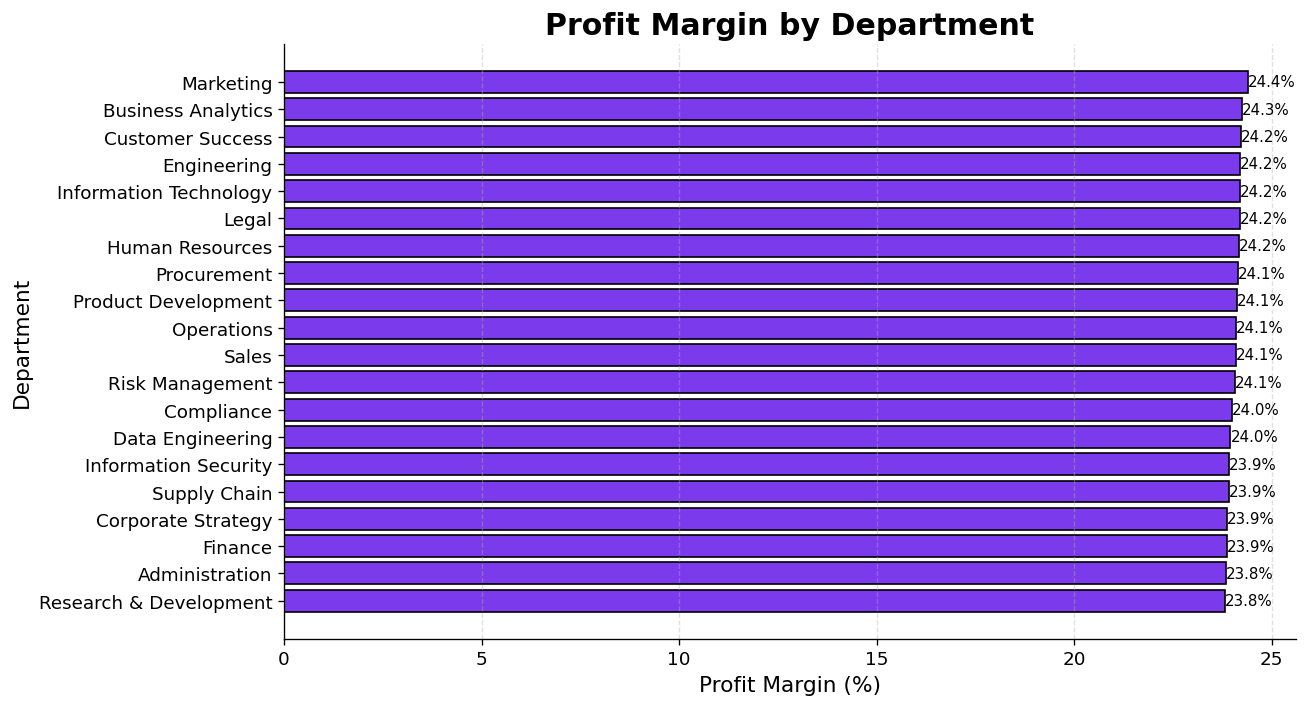

In [76]:
## PROFIT MARGIN BY DEPARTMENT

department_chart = department_summary.sort_values(
    "Profit Margin (%)",
    ascending=True
)

plt.figure(figsize=(11,6))

bars = plt.barh(
    department_chart["DepartmentName"],
    department_chart["Profit Margin (%)"],
    color="#7C3AED",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.title("Profit Margin by Department", fontsize=18, fontweight="bold")

plt.xlabel("Profit Margin (%)")
plt.ylabel("Department")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Key Insights

- Departments contribute differently to revenue and profitability.
- High revenue departments may not always have the highest profit margins.
- Comparing revenue and profit helps identify the most efficient departments.


### Conclusion

Department performance analysis highlights operational strengths and areas for improvement, supporting better resource allocation and strategic planning.    

# EDA 12: Business Unit Performance Analysis

## Objective

Evaluate the performance of each business unit by analyzing revenue, profit, transaction volume, and profit margin.

In [77]:
business_analysis = transactions.merge(
    business_units,
    on="BusinessUnitID",
    how="left",
    suffixes=("", "_BusinessUnit")
)

business_analysis.head()

,TransactionID,TransactionDate,CustomerID,ProductID,EmployeeID,DepartmentID,BusinessUnitID,RegionID,Quantity,UnitPrice,Revenue,COGS,OperatingExpense,Discount,Tax,Profit,SalesChannel,PaymentMethod,CustomerType,OrderStatus,MonthYear,BusinessUnitName,VicePresident,AnnualRevenueTarget
0,1,2024-08-17,23655,276,1967,3,1,6,2,"2,000.77","4,001.54","2,121.00",523.36,0.00,337.36,"1,357.18",Partner,Card,Individual,Completed,2024-08,Consumer Business,Allison Hill,"17,788,535.97"
1,2,2024-12-22,15796,485,416,16,8,2,19,138.19,"2,625.61","1,799.30",444.87,0.00,257.86,381.44,Online,Card,SMB,Completed,2024-12,Logistics,Gina Moore,"6,738,776.65"
2,3,2023-06-29,861,428,1766,5,7,4,17,"2,915.99","49,571.83","24,054.83","5,189.63","7,435.77","2,279.48","12,891.60",Online,Bank Transfer,Individual,Completed,2023-06,Media Services,Abigail Shaffer,"22,843,591.35"
3,4,2024-07-30,5391,427,1296,8,2,9,2,191.99,383.98,275.84,95.54,38.40,17.63,-25.80,Partner,Card,SMB,Completed,2024-07,Enterprise Solutions,Noah Rhodes,"5,500,215.10"
4,5,2023-06-23,21576,59,2205,14,8,8,6,"3,457.26","20,743.56","9,051.12","4,275.52","1,037.18","1,465.03","6,379.74",Partner,Wallet,Enterprise,Returned,2023-06,Logistics,Gina Moore,"6,738,776.65"


In [81]:
business_summary = (
    business_analysis
    .groupby(
        ["BusinessUnitName", "VicePresident", "AnnualRevenueTarget"],
        as_index=False
    )
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("TransactionID", "count"),
        Total_Quantity=("Quantity", "sum")
    )
)

business_summary["Profit Margin (%)"] = (
    business_summary["Total_Profit"]
    / business_summary["Total_Revenue"] * 100
).round(2)

business_summary["Target Achievement (%)"] = (
    business_summary["Total_Revenue"]
    / business_summary["AnnualRevenueTarget"] * 100
).round(2)

business_summary

,BusinessUnitName,VicePresident,AnnualRevenueTarget,Total_Revenue,Total_Profit,Total_Orders,Total_Quantity,Profit Margin (%),Target Achievement (%)
0,Cloud Services,Angie Henderson,"10,500,586.37","415,171,059.26","99,949,540.01",22293,223116,24.07,"3,953.79"
1,Consumer Business,Allison Hill,"17,788,535.97","413,780,280.37","99,231,865.43",22244,222326,23.98,"2,326.11"
2,Digital Products,Daniel Wagner,"9,464,214.76","415,920,690.72","100,395,272.07",22016,221356,24.14,"4,394.67"
3,Enterprise Solutions,Noah Rhodes,"5,500,215.10","410,096,579.83","97,904,580.37",22051,220664,23.87,"7,456.01"
4,Financial Services,Connie Lawrence,"18,533,989.75","418,651,707.68","100,723,110.16",22196,222906,24.06,"2,258.83"
5,International Business,Gabrielle Davis,"13,438,436.39","416,253,782.53","101,097,435.23",22277,223697,24.29,"3,097.49"
6,Logistics,Gina Moore,"6,738,776.65","417,542,679.11","101,368,122.18",22262,223482,24.28,"6,196.12"
7,Media Services,Abigail Shaffer,"22,843,591.35","414,161,768.73","98,957,133.76",22180,221667,23.89,"1,813.03"
8,Retail Operations,Cristian Santos,"19,729,424.28","419,915,732.74","101,100,118.35",22481,223789,24.08,"2,128.37"


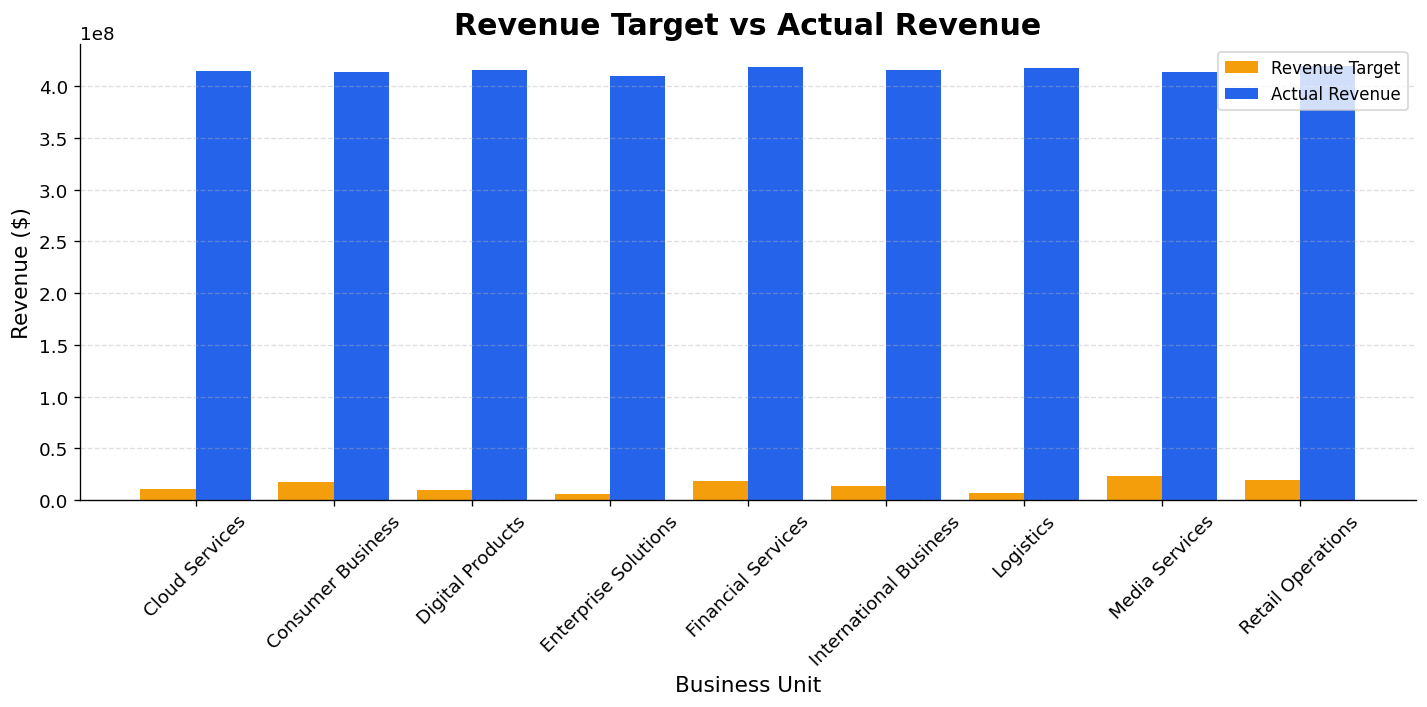

In [82]:
## REVENUE VS TARGET

plt.figure(figsize=(12,6))

x = range(len(business_summary))
width = 0.4

plt.bar(
    [i - width/2 for i in x],
    business_summary["AnnualRevenueTarget"],
    width=width,
    color="#F59E0B",
    label="Revenue Target"
)

plt.bar(
    [i + width/2 for i in x],
    business_summary["Total_Revenue"],
    width=width,
    color="#2563EB",
    label="Actual Revenue"
)

plt.xticks(
    x,
    business_summary["BusinessUnitName"],
    rotation=45
)

plt.title(
    "Revenue Target vs Actual Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Business Unit")
plt.ylabel("Revenue ($)")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [83]:
## TARGET ACHIVEMENT TABLE

business_summary[
    [
        "BusinessUnitName",
        "VicePresident",
        "AnnualRevenueTarget",
        "Total_Revenue",
        "Target Achievement (%)"
    ]
].sort_values(
    "Target Achievement (%)",
    ascending=False
)

,BusinessUnitName,VicePresident,AnnualRevenueTarget,Total_Revenue,Target Achievement (%)
3,Enterprise Solutions,Noah Rhodes,"5,500,215.10","410,096,579.83","7,456.01"
6,Logistics,Gina Moore,"6,738,776.65","417,542,679.11","6,196.12"
2,Digital Products,Daniel Wagner,"9,464,214.76","415,920,690.72","4,394.67"
0,Cloud Services,Angie Henderson,"10,500,586.37","415,171,059.26","3,953.79"
5,International Business,Gabrielle Davis,"13,438,436.39","416,253,782.53","3,097.49"
1,Consumer Business,Allison Hill,"17,788,535.97","413,780,280.37","2,326.11"
4,Financial Services,Connie Lawrence,"18,533,989.75","418,651,707.68","2,258.83"
8,Retail Operations,Cristian Santos,"19,729,424.28","419,915,732.74","2,128.37"
7,Media Services,Abigail Shaffer,"22,843,591.35","414,161,768.73","1,813.03"


### Key Insights

- Business units contribute differently to overall revenue and profit.
- Comparing actual revenue against targets highlights the highest-performing business units.
- Target achievement provides a clear measure of operational effectiveness.

### Conclusion

Business unit analysis evaluates operational performance by comparing actual revenue with revenue targets. This supports strategic planning, performance monitoring, and leadership decision-making.    

# EDA 13: Budget vs Actual Performance Analysis

## Objective

Compare planned budgets with actual business performance to identify variances and evaluate financial efficiency.

In [85]:
transactions["Year"] = transactions["TransactionDate"].dt.year
transactions["Month"] = transactions["TransactionDate"].dt.strftime("%B")

actual_summary = (
    transactions
    .groupby(
        ["DepartmentID", "Year", "Month"],
        as_index=False
    )
    .agg(
        ActualRevenue=("Revenue", "sum"),
        ActualExpense=("COGS", "sum"),
        ActualProfit=("Profit", "sum")
    )
)

actual_summary.head()

,DepartmentID,Year,Month,ActualRevenue,ActualExpense,ActualProfit
0,1,2023,April,"5,319,609.81","2,856,750.55","1,291,207.36"
1,1,2023,August,"5,509,572.88","2,942,654.18","1,337,033.85"
2,1,2023,December,"4,801,207.67","2,562,871.22","1,148,205.22"
3,1,2023,February,"4,736,566.39","2,494,382.05","1,190,964.51"
4,1,2023,January,"5,331,176.96","2,905,778.06","1,211,503.16"


In [86]:
budget_analysis = budget.merge(
    actual_summary,
    on=["DepartmentID", "Year", "Month"],
    how="left"
)

budget_analysis.head()

,BudgetID,Year,Month,DepartmentID,BudgetRevenue,BudgetExpense,BudgetProfit,ActualRevenue,ActualExpense,ActualProfit
0,1,2023,January,1,"446,997.41","249,649.61","197,347.80","5,331,176.96","2,905,778.06","1,211,503.16"
1,2,2023,January,2,"124,129.08","91,542.57","32,586.51","5,515,081.83","2,940,592.60","1,334,242.75"
2,3,2023,January,3,"303,300.01","196,853.93","106,446.08","5,224,358.12","2,768,866.22","1,297,786.66"
3,4,2023,January,4,"115,051.89","84,422.52","30,629.37","5,339,709.32","2,803,512.54","1,334,604.69"
4,5,2023,January,5,"225,658.17","148,937.64","76,720.53","5,964,198.78","3,127,855.76","1,486,168.88"


In [87]:
budget_analysis["Revenue Variance"] = (
    budget_analysis["ActualRevenue"] -
    budget_analysis["BudgetRevenue"]
)

budget_analysis["Expense Variance"] = (
    budget_analysis["ActualExpense"] -
    budget_analysis["BudgetExpense"]
)

budget_analysis["Profit Variance"] = (
    budget_analysis["ActualProfit"] -
    budget_analysis["BudgetProfit"]
)

budget_analysis.head()

,BudgetID,Year,Month,DepartmentID,BudgetRevenue,BudgetExpense,BudgetProfit,ActualRevenue,ActualExpense,ActualProfit,Revenue Variance,Expense Variance,Profit Variance
0,1,2023,January,1,"446,997.41","249,649.61","197,347.80","5,331,176.96","2,905,778.06","1,211,503.16","4,884,179.55","2,656,128.45","1,014,155.36"
1,2,2023,January,2,"124,129.08","91,542.57","32,586.51","5,515,081.83","2,940,592.60","1,334,242.75","5,390,952.75","2,849,050.03","1,301,656.24"
2,3,2023,January,3,"303,300.01","196,853.93","106,446.08","5,224,358.12","2,768,866.22","1,297,786.66","4,921,058.11","2,572,012.29","1,191,340.58"
3,4,2023,January,4,"115,051.89","84,422.52","30,629.37","5,339,709.32","2,803,512.54","1,334,604.69","5,224,657.43","2,719,090.02","1,303,975.32"
4,5,2023,January,5,"225,658.17","148,937.64","76,720.53","5,964,198.78","3,127,855.76","1,486,168.88","5,738,540.61","2,978,918.12","1,409,448.35"


In [89]:
budget_analysis["Revenue Variance (%)"] = (
    budget_analysis["Revenue Variance"]
    / budget_analysis["BudgetRevenue"] * 100
).round(2)

budget_analysis["Profit Variance (%)"] = (
    budget_analysis["Profit Variance"]
    / budget_analysis["BudgetProfit"] * 100
).round(2)

budget_analysis.head()

,BudgetID,Year,Month,DepartmentID,BudgetRevenue,BudgetExpense,BudgetProfit,ActualRevenue,ActualExpense,ActualProfit,Revenue Variance,Expense Variance,Profit Variance,Revenue Variance (%),Profit Variance (%)
0,1,2023,January,1,"446,997.41","249,649.61","197,347.80","5,331,176.96","2,905,778.06","1,211,503.16","4,884,179.55","2,656,128.45","1,014,155.36","1,092.66",513.89
1,2,2023,January,2,"124,129.08","91,542.57","32,586.51","5,515,081.83","2,940,592.60","1,334,242.75","5,390,952.75","2,849,050.03","1,301,656.24","4,343.02","3,994.46"
2,3,2023,January,3,"303,300.01","196,853.93","106,446.08","5,224,358.12","2,768,866.22","1,297,786.66","4,921,058.11","2,572,012.29","1,191,340.58","1,622.51","1,119.20"
3,4,2023,January,4,"115,051.89","84,422.52","30,629.37","5,339,709.32","2,803,512.54","1,334,604.69","5,224,657.43","2,719,090.02","1,303,975.32","4,541.13","4,257.27"
4,5,2023,January,5,"225,658.17","148,937.64","76,720.53","5,964,198.78","3,127,855.76","1,486,168.88","5,738,540.61","2,978,918.12","1,409,448.35","2,543.02","1,837.12"


In [90]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_budget = (
    budget_analysis
    .groupby(["Year", "Month"], as_index=False)
    .agg(
        BudgetRevenue=("BudgetRevenue","sum"),
        ActualRevenue=("ActualRevenue","sum")
    )
)

monthly_budget["Month"] = pd.Categorical(
    monthly_budget["Month"],
    categories=month_order,
    ordered=True
)

monthly_budget = monthly_budget.sort_values(["Year","Month"])

monthly_budget["MonthYear"] = (
    monthly_budget["Month"].astype(str)
    + " "
    + monthly_budget["Year"].astype(str)
)

monthly_budget.head()

,Year,Month,BudgetRevenue,ActualRevenue,MonthYear
4,2023,January,"5,456,051.70","104,919,765.50",January 2023
3,2023,February,"5,425,068.94","93,340,867.99",February 2023
7,2023,March,"6,285,727.57","107,438,781.60",March 2023
0,2023,April,"6,391,059.89","104,614,585.80",April 2023
8,2023,May,"6,676,688.21","107,893,013.92",May 2023


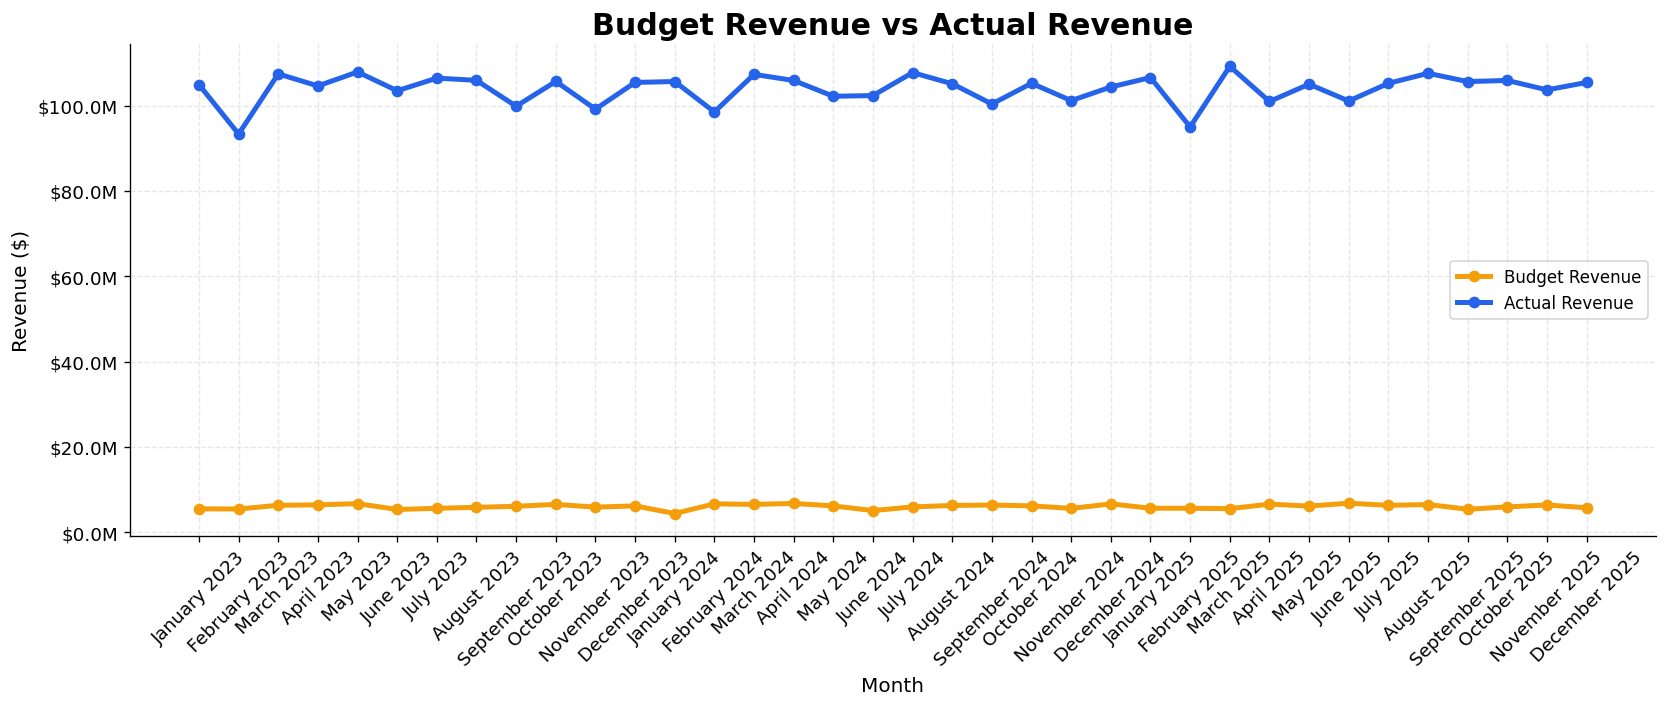

In [91]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(14,6))

plt.plot(
    monthly_budget["MonthYear"],
    monthly_budget["BudgetRevenue"],
    marker="o",
    linewidth=3,
    color="#F59E0B",
    label="Budget Revenue"
)

plt.plot(
    monthly_budget["MonthYear"],
    monthly_budget["ActualRevenue"],
    marker="o",
    linewidth=3,
    color="#2563EB",
    label="Actual Revenue"
)

plt.title(
    "Budget Revenue vs Actual Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

plt.grid(alpha=0.3, linestyle="--")

plt.legend()

plt.tight_layout()

plt.show()

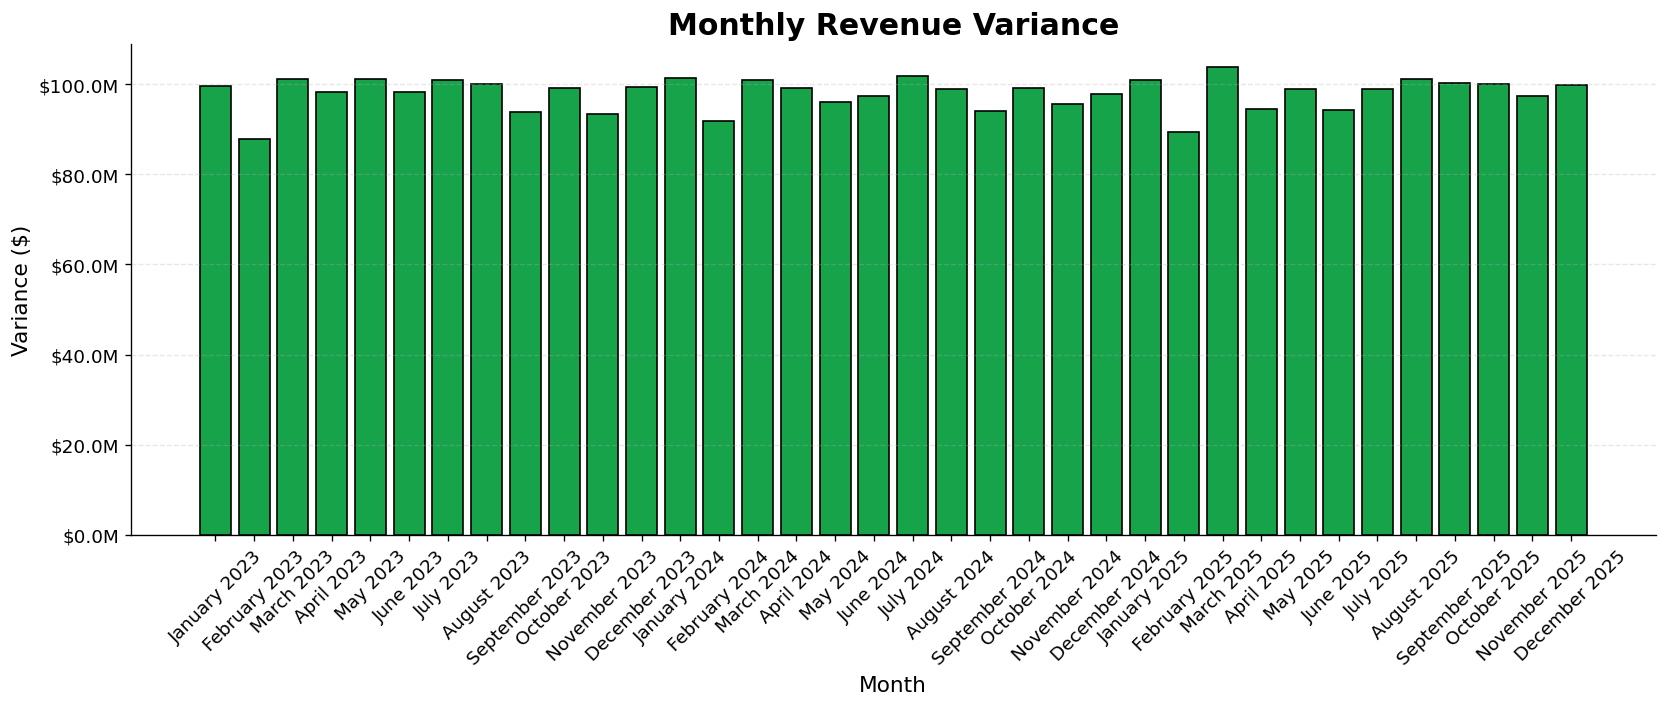

In [92]:
monthly_budget["Variance"] = (
    monthly_budget["ActualRevenue"]
    - monthly_budget["BudgetRevenue"]
)

plt.figure(figsize=(14,6))

colors = [
    "#16A34A" if x >= 0 else "#DC2626"
    for x in monthly_budget["Variance"]
]

bars = plt.bar(
    monthly_budget["MonthYear"],
    monthly_budget["Variance"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Monthly Revenue Variance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Variance ($)")

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

# Final Conclusion

This exploratory data analysis provided a comprehensive assessment of the organization's financial and operational performance using Python. The analysis covered revenue, profit, expenses, regional performance, product performance, customer behavior, employee productivity, department efficiency, business unit performance, and budget vs. actual comparisons.

Key findings showed that revenue and profitability varied across regions, products, departments, and business units, highlighting opportunities to improve operational efficiency and resource allocation. Customer and employee analyses identified the highest-value contributors, while budget variance analysis revealed areas where actual performance differed from financial targets.

Overall, the analysis demonstrates how data can be transformed into actionable business insights to support strategic planning, financial decision-making, performance monitoring, and operational optimization. The cleaned and analyzed data is now ready for advanced SQL analysis and interactive Power BI dashboards, enabling executives to monitor key performance indicators and make data-driven business decisions.